# Lab One: Exploring Table Data

Group Members: David Guo, Zi Ling

## 1.Business Understanding

Amazon has millions of products and serves users worldwide, providing an open platform for sellers to generate revenue. However, competition is fierce among sellers, so sellers always make a great effort on the marketing strategy to stand out among other products.

As a result, it is essential for sellers to understand which operations or attributes influence sales the most and to adjust their operational strategies based on data-driven insights. Since even a small operational decision will impact the sales performance significantly, such as price adjustments, review management. So, it's necessary to build a predictive model for sellers, which can help sellers to predict the product sales outcomes based on the marketing strategy. Moreover, sellers can also create various marketing strategies and choose the best toolkit based on the predictive purchase amount. Therefore, the predictive model will help sellers to make data-driven decisions and save marketing costs.

To support this analysis, we use the Amazon Electronics Products Sales Dataset from Kaggle. This dataset focuses on electronic products like laptops, phones, with 42,675 rows and 17 features, including the original price, discount price, product rating, sponsored status, and more. Many of these features align with the marketing decisions and how consumers make purchasing decisions on Amazon, so the dataset is intuitive and suitable for our project.

This dataset was created by Ikram Ul Hassan for research and educational purposes, was scraping publicly available data from Amazon's official website using Python-based web scraping techniques. 

There are two versions of the dataset: a raw (uncleaned) version and a cleaned version. For this project, we selected the cleaned dataset to ensure high-quality data for our analysis.

============================================================================================================
    
Dataset URL: https://www.kaggle.com/datasets/ikramshah512/amazon-products-sales-dataset-42k-items-2025/data 

Questions of Interest: Predict the electronic product purchase amount on Amazon, based on giving marketing stragegies (discount, sponsor, etc.)

# 2.Data understanding

### 2.1 Original Attributes

In [290]:
#load dataset (code from MachineLearningNotebook)
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("amazon_products_sales_data_cleaned.csv")

df.head()

,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Phones,43.60
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,37.52
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,No Badge,Sponsored,No Coupon,Add to cart,2025-09-01,NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,10.03
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,162.24,162.24,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,https://www.amazon.com/Apple-Cancellation-Tran...,2025-08-21 11:14:29,Phones,0.00
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,72.74,72.74,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,https://www.amazon.com/Apple-MX542LL-A-AirTag-...,2025-08-21 11:14:29,Phones,0.00


In [291]:
# create a data description table (code from Lab One example)
data_des = pd.DataFrame()

data_des['Features'] = df.columns
data_des['Description'] = [  'Complete name/title of the product',
    'Average customer rating (numeric) out of 5',
    'Total number of customer reviews',
    'Units purchased in the last month',
    'Current price after discount',
    'Original listed price before discount',
    'Percentage discount applied to the product',
    'Indicates if the product is tagged as a Best Seller',
    'Whether the product is a Sponsored item or Organic',
    'Special discounted coupons availability (True/False)',
    'BuyBox button availability on Amazon search page (NaN values represent False)',
    'Estimated delivery date (converted to datetime format)',
    'Eco-friendly and sustainability-related tags',
    'Direct image link of the product',
    'Official Amazon product page URL',
    'Date when the data was collected',
    'Assigned product category based on the title' ]

data_des

,Features,Description
0,product_title,Complete name/title of the product
1,product_rating,Average customer rating (numeric) out of 5
2,total_reviews,Total number of customer reviews
3,purchased_last_month,Units purchased in the last month
4,discounted_price,Current price after discount
5,original_price,Original listed price before discount
6,is_best_seller,Percentage discount applied to the product
7,is_sponsored,Indicates if the product is tagged as a Best S...
8,has_coupon,Whether the product is a Sponsored item or Org...
9,buy_box_availability,Special discounted coupons availability (True/...


In [292]:
# find data type and null value (code from MachineLearningNotebook)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_title         42675 non-null  object 
 1   product_rating        41651 non-null  float64
 2   total_reviews         41651 non-null  float64
 3   purchased_last_month  32164 non-null  float64
 4   discounted_price      40613 non-null  float64
 5   original_price        40613 non-null  float64
 6   is_best_seller        42675 non-null  object 
 7   is_sponsored          42675 non-null  object 
 8   has_coupon            42675 non-null  object 
 9   buy_box_availability  28022 non-null  object 
 10  delivery_date         30692 non-null  object 
 11  sustainability_tags   3408 non-null   object 
 12  product_image_url     42675 non-null  object 
 13  product_page_url      40606 non-null  object 
 14  data_collected_at     42675 non-null  object 
 15  product_category   



The original dataset contains 17 features.

However, not all attributes are useful in modelling, so we select the most relevant ones.

1. The product specification attributes are important for identifying the product; therefore, we include product_category, and original_price. Although sustainability_tags seems important, most value is missing, so we exclude it.

2. Marketing-related attributes are necessary since they reflect key operational decisions in marketing. So, we include discounted_price, discount_percentage, and is_sponsored. Has_coupon is not included since most products don't have coupons. Although discount_percentage seems to be redundant as it's computed from original_price and discount_price, it's still valuable since original_price has a significant gap among electronic products, so even if the discount_price are the same, consumers may choose the one with a higher discount_percentage.

3. The review-related attributes are also important because consumers care about both price and quality. Intuitively, products with higher ratings and a large number of reviews are perceived as a better choice.

4. The sales-outcome-related attributes matter. We treat purchased_last_month as the predictive feature, since it can be considered as the sales outcomes. Is_best_seller is also a motivation for consumers to purchase the product, so it's included.

5. Some attributes are not suitable for the model. Although date_collected_at and the delivery_date could be used to calculate delivery efficiency, they are highly influenced by whether the consumer is a Prime member. Therefore, we exclude both. Then the buy_box_availability contains many missing values and is not directly controllable by the seller, and product_image_url, product_page_url are not suitable for our table data analysis, so we exclude them as well.

In [293]:
# select included attributes and create a new dataset 
# (code from https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html)
import copy

df_deepcopy = copy.deepcopy(df)
selected_df = df_deepcopy.drop(["product_title","has_coupon", "product_page_url", "data_collected_at", "product_image_url", "sustainability_tags", "delivery_date", "buy_box_availability"], axis=1)

selected_df.head()

,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,product_category,discount_percentage
0,4.6,375.0,300.0,89.68,159.00,No Badge,Sponsored,Phones,43.60
1,4.3,2457.0,6000.0,9.99,15.99,No Badge,Sponsored,Laptops,37.52
2,4.6,3044.0,2000.0,314.00,349.00,No Badge,Sponsored,Laptops,10.03
3,4.6,35882.0,10000.0,162.24,162.24,Best Seller,Organic,Phones,0.00
4,4.8,28988.0,10000.0,72.74,72.74,No Badge,Organic,Phones,0.00



Finally, we have a dataset with 9 attributes, including:

product_rating, total_reviews, purchased_last_month, discounted_price, original_price, is_best_seller, is_sponsored, product_category, discount_percentage.

In addition, although we used the cleaned dataset as the author describes, there are still many missing values in several attributes. So we also perform the data cleaning process, and the details are in 2.4 Data Quality.

### 2.2 Data Type 

In [294]:
#find data type (code from MachineLearningNotebook)
selected_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_rating        41651 non-null  float64
 1   total_reviews         41651 non-null  float64
 2   purchased_last_month  32164 non-null  float64
 3   discounted_price      40613 non-null  float64
 4   original_price        40613 non-null  float64
 5   is_best_seller        42675 non-null  object 
 6   is_sponsored          42675 non-null  object 
 7   product_category      42675 non-null  object 
 8   discount_percentage   40613 non-null  float64
dtypes: float64(6), object(3)
memory usage: 2.9+ MB


In [295]:
# find distinct values in each object attribute
# code from https://pandas.pydata.org/docs/reference/api/pandas.unique.html

# is_best_seller
print("is_best_seller:", df['is_best_seller'].unique())

# is_sponsored
print("is_sponsored:", df['is_sponsored'].unique())

# product_category
print("product_category:", df['product_category'].unique())

is_best_seller: ['No Badge' 'Best Seller' "Amazon's" 'Limited time deal' 'Save 30%'
 'Save 12%' 'Save 9%' 'Save 17%' 'Save 77%' 'Ends in' 'Save 10%'
 'Save 18%']
is_sponsored: ['Sponsored' 'Organic']
product_category: ['Phones' 'Laptops' 'Other Electronics' 'Cameras' 'Storage'
 'Printers & Scanners' 'TV & Display' 'Power & Batteries'
 'Chargers & Cables' 'Headphones' 'Networking' 'Speakers' 'Wearables'
 'Gaming' 'Smart Home']


According to the info, the data type of product_title, product_rating, discounted_price, original_price, and discount_percentage are correct.

However, some attributes need to be fixed in the datatype:
1. total_review , it means the total number of reviews of a specific product, so it should be an integer， not a float.
2. purchase_last_month, it means Units purchased in the last month, so it should be an integer as well.
3. is_best_seller, has twelve distinct values, in this case, we can use one-hot-encoding to achieve a better data type and representation. Although the "Ends in" seems like a missing value, we treat it as a limited promotion badge rather than consider it missing, because limited promotion usually works well.
4. is_sponsored, has two distinct values: "Organic" or "Sponsored", so we can change the data type into boolean, replace "Organic" with 0, and "Sponsored" with 1.
5. product_category, has fifteen values, similar with is_best_seller, we can also do one hot encoding here.

Since there are many missing values in the dataset, we can't fix all the data types with missing values, so this work will be done after cleaning the dataset.
   

### 2.3 Statistics Description

In [296]:
#find statistics summary 
selected_df.describe()

,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,discount_percentage
count,41651.000000,41651.000000,32164.000000,40613.000000,40613.000000,40613.000000
mean,4.399431,3087.106000,1293.665278,243.227289,257.611107,6.547151
std,0.386997,13030.460133,6318.323574,473.351545,496.633495,12.744715
min,1.000000,1.000000,50.000000,2.160000,2.160000,0.000000
25%,4.200000,82.000000,100.000000,29.690000,32.990000,0.000000
50%,4.500000,343.000000,200.000000,84.990000,89.000000,0.000000
75%,4.700000,1886.000000,400.000000,224.000000,229.990000,8.490000
max,5.000000,865598.000000,100000.000000,5449.000000,5449.000000,85.420000


According to the statistics table, we can catch useful information in each attribute:

1. product_rating: range is 1-5, no weird value. Mean is 4.39 and std is 0.39, which means the ratings are generally high and pretty close among products.
2. total_reviews： range is 1-865,598, and the mean is 3087, 50% is 343, which means total_reviews is skewed distributed. This distribution is consistent with common sense, since only a small number of products achieve high sales.
3. Purchase_last_month: similar to total_review, the distribution is strongly right-skewed, may need log scaling for visualization.
4. Discounted_price and original_price: these two attributes are correlated, and their statistics are consistent as well, so no outliers.
5. Discounted_percentage: is between 0 to 85.42, it's possible on Amazon, so no outlier.

Non-numerical attributes are not included in the description table. However, in 2.2 Data Type, we already discussed the  values of each attribute. There is no missing value, no outliers in those features, which are is_better_seller, is_sponsored, and product_category.

### 2.4 Data Quality

#### 2.4.1 Visualization of Missing Data

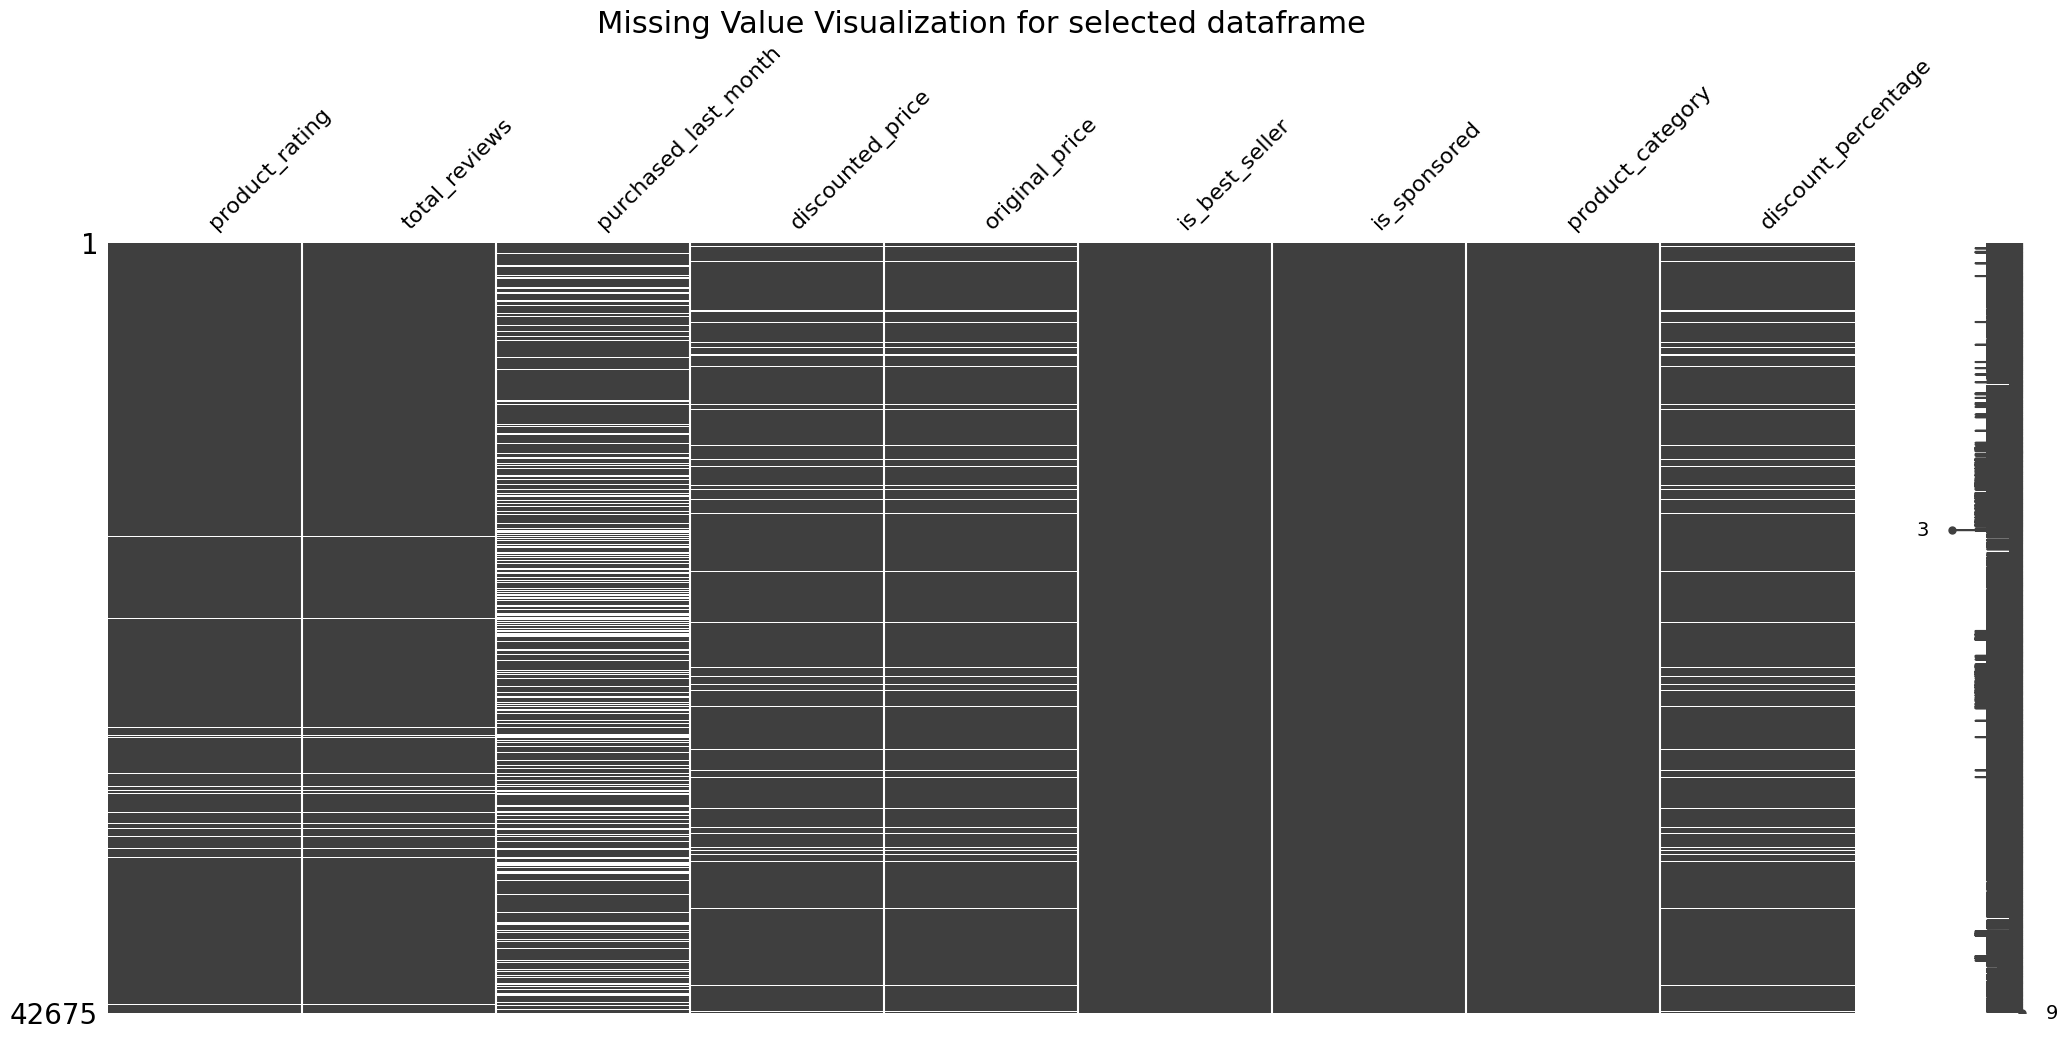

<Figure size 640x480 with 0 Axes>

Missing Percentage of Selected Attributes 
product_rating           2.399531
total_reviews            2.399531
purchased_last_month    24.630346
discounted_price         4.831869
original_price           4.831869
is_best_seller           0.000000
is_sponsored             0.000000
product_category         0.000000
discount_percentage      4.831869
dtype: float64


In [297]:

import matplotlib
import matplotlib.pyplot as plt

import missingno as mn

#Created a function to visualized missing value where the parameter expects a dataframe
#(code from Titanic example)
def visualizedMissingMatrix(df, title):
	mn.matrix(df)
	plt.title(title,fontsize=22)

	plt.figure()
	plt.show()


#Created a function to calculate missing value where the parameter expects a dataframe
def calculate_missing_values(df):
	return (df.isnull().sum()/df.shape[0]) * 100

visualizedMissingMatrix(selected_df, "Missing Value Visualization for selected dataframe")
missing_percentage_per_column = calculate_missing_values(selected_df)
print(f"Missing Percentage of Selected Attributes \n{missing_percentage_per_column}")

There are six attributes that contain missing values. The possible reasons include:

It may be because the product was newly listed, so most of the attributes like product rating, total reviews, etc, are not listed yet, as not many people have bought the product, so there is no product rating or review. 

As for the price, some products may be unavailable in specific locations or sold out. so the original_price, discounted_price, and the discounted_percentage.

Also, this dataset was created by scraping publicly available data from Amazon's official website using Python-based web scraping techniques, so some values are not captured.

#### 2.4.2 Dropping Missing Data That is Not Suitable for Imputation


From a quick glance at the matrix, the data has quite a few missing data. According to the missing percentage, most attributes have a missing percentage of less than 5%, however, purchased_last_month has significantly more missing values than the rest, with a percentage of 24.6%. Moreover, since purchased_last_month is the target attribute we want to use to perform a prediction on, we would have to drop it.

<class 'pandas.core.frame.DataFrame'>
Index: 32164 entries, 0 to 42674
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_rating        32088 non-null  float64
 1   total_reviews         32088 non-null  float64
 2   purchased_last_month  32164 non-null  float64
 3   discounted_price      30304 non-null  float64
 4   original_price        30304 non-null  float64
 5   is_best_seller        32164 non-null  object 
 6   is_sponsored          32164 non-null  object 
 7   product_category      32164 non-null  object 
 8   discount_percentage   30304 non-null  float64
dtypes: float64(6), object(3)
memory usage: 2.5+ MB


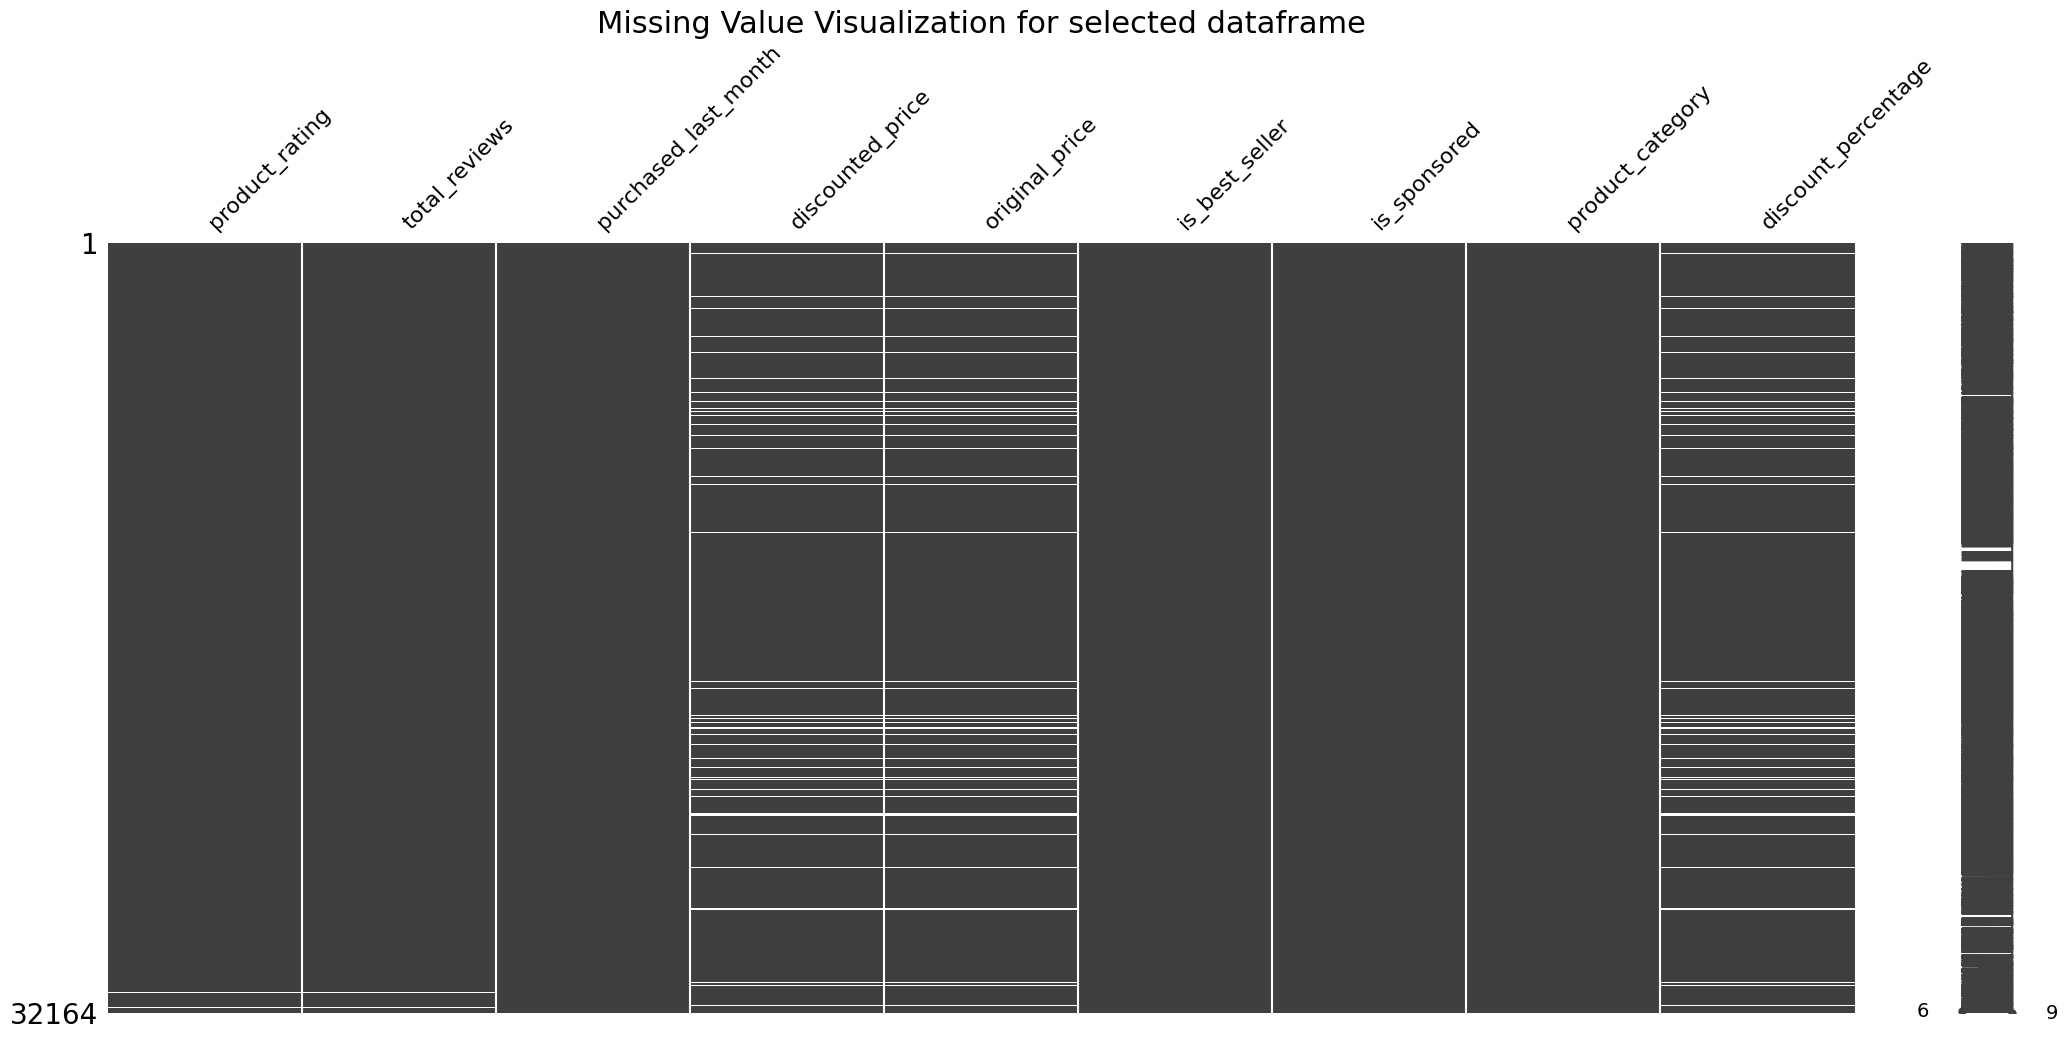

<Figure size 640x480 with 0 Axes>

Missing Percentage of Selected Attributes 
product_rating          0.236289
total_reviews           0.236289
purchased_last_month    0.000000
discounted_price        5.782863
original_price          5.782863
is_best_seller          0.000000
is_sponsored            0.000000
product_category        0.000000
discount_percentage     5.782863
dtype: float64


In [298]:
##Starting the process of dropping the purchased last month feature.

drop_purchased_last_month_missing_value = selected_df.dropna(subset=["purchased_last_month"])

drop_purchased_last_month_missing_value.info()


visualizedMissingMatrix(drop_purchased_last_month_missing_value, "Missing Value Visualization for selected dataframe")
missing_percentage_per_column_dropped_values = calculate_missing_values(drop_purchased_last_month_missing_value)
print(f"Missing Percentage of Selected Attributes \n{missing_percentage_per_column_dropped_values}")


Even after dropping the missing values in the purchased_last_month column, there were additional missing values as well for product_rating, total_reviews, discounted_price, original_price, and discounted_percentage. The missing values for all seem to be for the same row, and this is also verified by looking at the missing matrix. This means that the features are related to one another, and this is shown as discounted percentage is a derived feature from original_price, and discount_price. Additionally, product_rating is depended on total_reviews, as if there are no product ratings that would mean that the product has no reviews yet, or it was just newly listed when the data was collected. 

As a result, we would need to drop discount_percentage, original_price, and discounted price as there are still 5.8% of missing data. 

Missing Percentage of Selected Attributes 
product_rating          0.250792
total_reviews           0.250792
purchased_last_month    0.000000
discounted_price        0.000000
original_price          0.000000
is_best_seller          0.000000
is_sponsored            0.000000
product_category        0.000000
discount_percentage     0.000000
dtype: float64


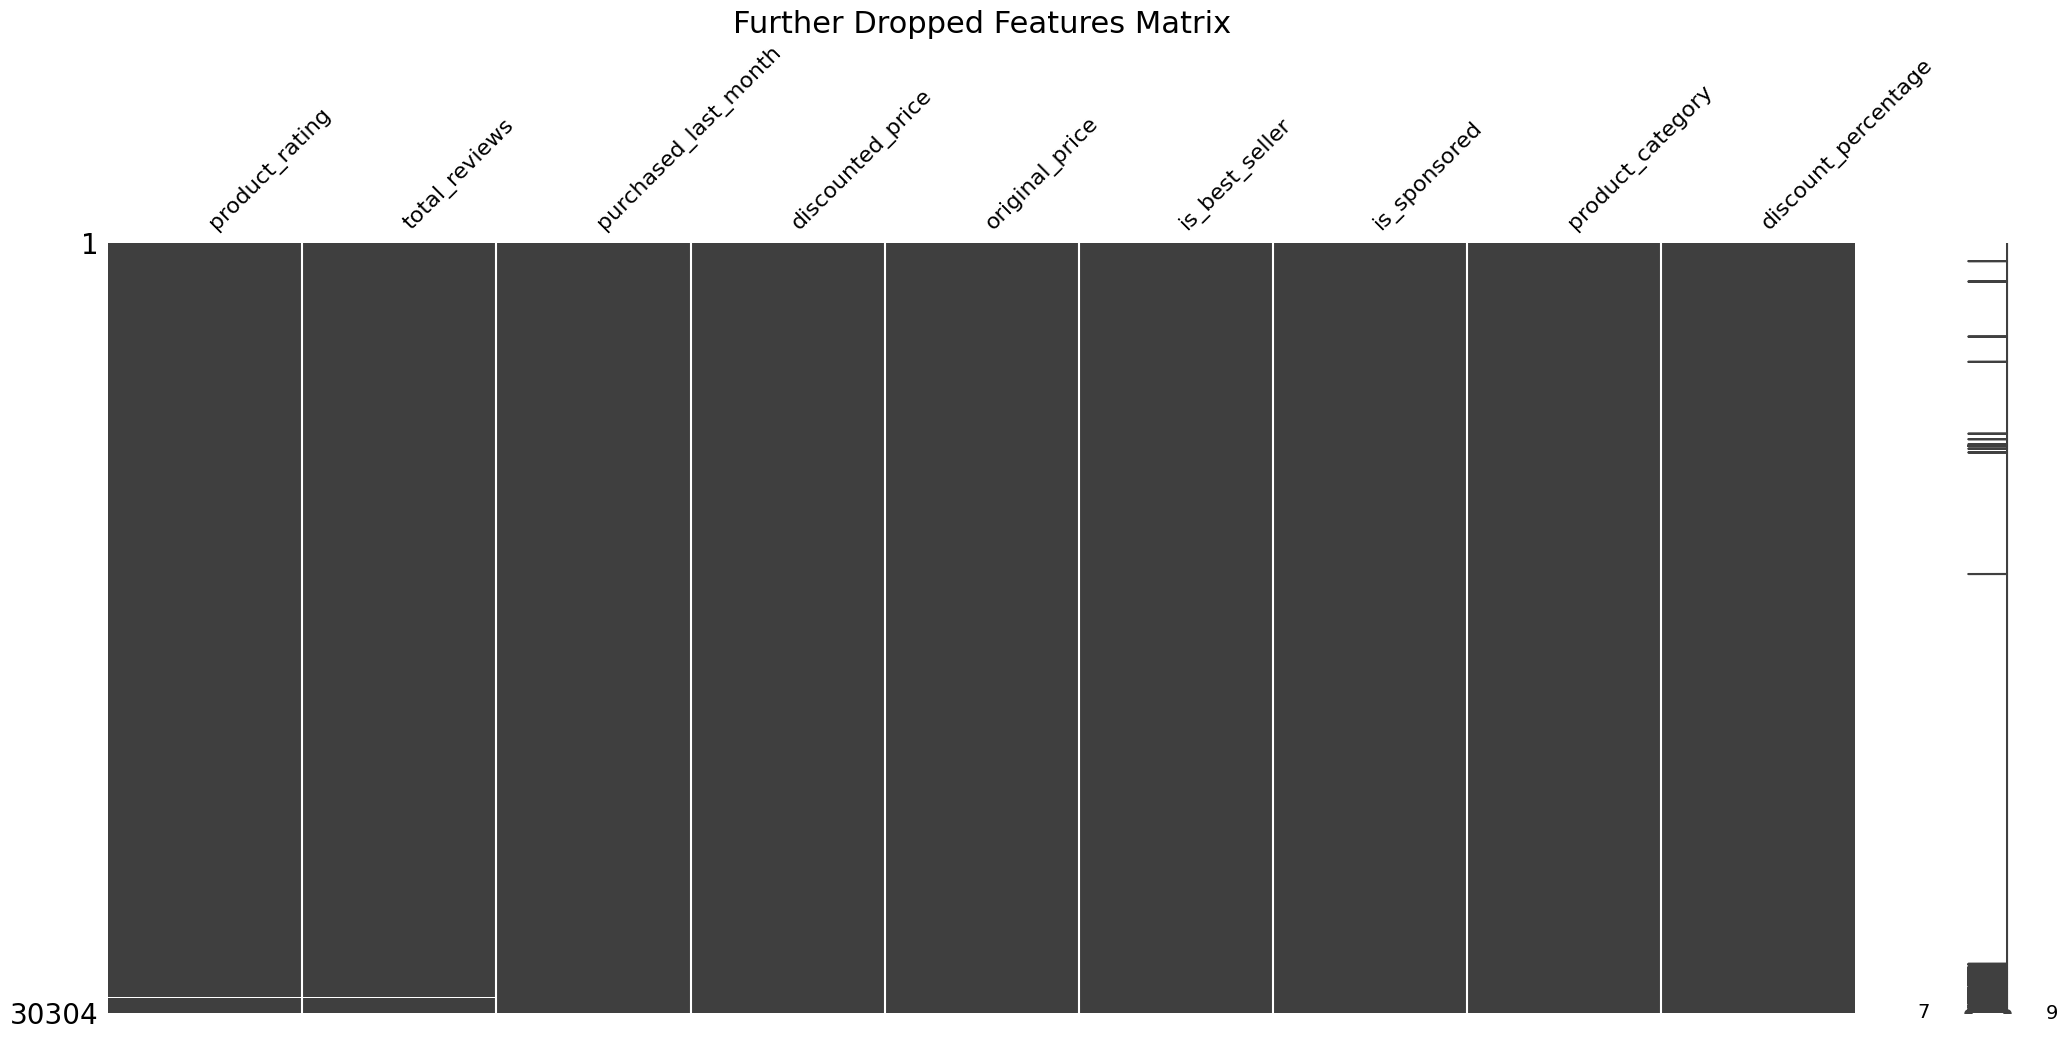

<Figure size 640x480 with 0 Axes>

Number of rows for final_df: 30304
product_rating          76
total_reviews           76
purchased_last_month     0
discounted_price         0
original_price           0
is_best_seller           0
is_sponsored             0
product_category         0
discount_percentage      0
dtype: int64


In [299]:
#Dropping additionally 

final_df = drop_purchased_last_month_missing_value.dropna(subset=["discounted_price", "original_price", "discount_percentage"])

further_dropped_percentage = calculate_missing_values(final_df)
print(f"Missing Percentage of Selected Attributes \n{further_dropped_percentage}")

visualizedMissingMatrix(final_df, "Further Dropped Features Matrix")
print(f"Number of rows for final_df: {final_df.shape[0]}")
print(final_df.isnull().sum())


There seems to be still some missing values, but since the percentage of missing value is low, we can start to impute them. 

#### 2.4.3 Starting Imputing Using Split-Impute-Combine Method

In [300]:
#Taken code from Professor Larson titanic lab1

column_names = [
    'product_rating',
    'total_reviews',
    'purchased_last_month',
    'discounted_price',
    'original_price',
    'is_best_seller',
    'is_sponsored',
    'product_category',
    'discount_percentage'
]

df_grouped = final_df.groupby(by=['product_category','original_price'])
func = lambda grp: grp.fillna(grp.mean())

numeric_columns = ['product_rating','total_reviews','purchased_last_month','discounted_price','original_price','discount_percentage']
df_imputed_sic_selected = df_grouped[numeric_columns].transform(func)


col_deleted = list( set(final_df.columns) - set(df_imputed_sic_selected.columns))
df_imputed_sic_selected[col_deleted] = df[col_deleted]

df_imputed_sic_selected.dropna(inplace=True)


df_imputed_sic = df_imputed_sic_selected[column_names]
df_imputed_sic_selected.info()
calculate_missing_values(df_imputed_sic_selected)
print(df_imputed_sic_selected.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 30298 entries, 0 to 42674
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_rating        30298 non-null  float64
 1   total_reviews         30298 non-null  float64
 2   purchased_last_month  30298 non-null  float64
 3   discounted_price      30298 non-null  float64
 4   original_price        30298 non-null  float64
 5   discount_percentage   30298 non-null  float64
 6   product_category      30298 non-null  object 
 7   is_best_seller        30298 non-null  object 
 8   is_sponsored          30298 non-null  object 
dtypes: float64(6), object(3)
memory usage: 2.3+ MB
product_rating          0
total_reviews           0
purchased_last_month    0
discounted_price        0
original_price          0
discount_percentage     0
product_category        0
is_best_seller          0
is_sponsored            0
dtype: int64


#### 2.4.4 Starting Imputing Using KNN

Firstly, convert object features into one hot encoding.

In [301]:

# Taken steps from https://www.geeksforgeeks.org/machine-learning/ml-one-hot-encoding/ on how to perform one hot encoding
from sklearn.preprocessing import OneHotEncoder


encoder = OneHotEncoder(sparse_output=False)

one_hot_encoded = encoder.fit_transform(final_df[['product_category', 'is_best_seller']])

one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(['product_category', 'is_best_seller']), index=final_df.index) #Used GPT to debug this as this was creating more rows then expected

df_encoded_for_knn = pd.concat([final_df, one_hot_df], axis=1)

df_encoded_for_knn["is_sponsored"] = df_encoded_for_knn["is_sponsored"].map({"Sponsored": 1, "Organic": 0})

'''Dropping categorical values'''
df_encoded_for_knn = df_encoded_for_knn.drop(['product_category', 'is_best_seller'], axis=1)

In [302]:
'''Checking to see if it encoded properly and to see no additional missing value was introduced'''

df_encoded_for_knn.info()
calculate_missing_values(df_encoded_for_knn)

<class 'pandas.core.frame.DataFrame'>
Index: 30304 entries, 0 to 42674
Data columns (total 31 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   product_rating                        30228 non-null  float64
 1   total_reviews                         30228 non-null  float64
 2   purchased_last_month                  30304 non-null  float64
 3   discounted_price                      30304 non-null  float64
 4   original_price                        30304 non-null  float64
 5   is_sponsored                          30304 non-null  int64  
 6   discount_percentage                   30304 non-null  float64
 7   product_category_Cameras              30304 non-null  float64
 8   product_category_Chargers & Cables    30304 non-null  float64
 9   product_category_Gaming               30304 non-null  float64
 10  product_category_Headphones           30304 non-null  float64
 11  product_category_Lap

product_rating                          0.250792
total_reviews                           0.250792
purchased_last_month                    0.000000
discounted_price                        0.000000
original_price                          0.000000
is_sponsored                            0.000000
discount_percentage                     0.000000
product_category_Cameras                0.000000
product_category_Chargers & Cables      0.000000
product_category_Gaming                 0.000000
product_category_Headphones             0.000000
product_category_Laptops                0.000000
product_category_Networking             0.000000
product_category_Other Electronics      0.000000
product_category_Phones                 0.000000
product_category_Power & Batteries      0.000000
product_category_Printers & Scanners    0.000000
product_category_Smart Home             0.000000
product_category_Speakers               0.000000
product_category_Storage                0.000000
product_category_TV 

Second, Starting imputation for total_reviews, and product_rating using KNN

In [303]:
# Taken Imputation steps from Professor Larson KNN code block
from sklearn.impute import KNNImputer

num_neighbors = 5
knn_obj = KNNImputer(n_neighbors=num_neighbors)

features_to_use = ['product_rating', 'total_reviews', 'purchased_last_month',
       'discounted_price', 'original_price', 'discount_percentage',
       'product_category_Cameras', 'product_category_Chargers & Cables',
       'product_category_Gaming', 'product_category_Headphones',
       'product_category_Laptops', 'product_category_Networking',
       'product_category_Other Electronics', 'product_category_Phones',
       'product_category_Power & Batteries',
       'product_category_Printers & Scanners', 'product_category_Smart Home',
       'product_category_Speakers', 'product_category_Storage',
       'product_category_TV & Display', 'product_category_Wearables',
       "is_best_seller_Amazon's", 'is_best_seller_Best Seller',
       'is_best_seller_Ends in', 'is_best_seller_Limited time deal',
       'is_best_seller_No Badge', 'is_best_seller_Save 12%',
       'is_best_seller_Save 17%', 'is_best_seller_Save 18%',
       'is_best_seller_Save 30%', 'is_sponsored']

temp = df_encoded_for_knn[features_to_use].to_numpy()
temp_imputed = knn_obj.fit_transform(temp)

df_imputed_knn = copy.deepcopy(df_encoded_for_knn)
df_imputed_knn[features_to_use] = temp_imputed
df_imputed_knn.dropna(inplace=True)
df_imputed_knn.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30304 entries, 0 to 42674
Data columns (total 31 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   product_rating                        30304 non-null  float64
 1   total_reviews                         30304 non-null  float64
 2   purchased_last_month                  30304 non-null  float64
 3   discounted_price                      30304 non-null  float64
 4   original_price                        30304 non-null  float64
 5   is_sponsored                          30304 non-null  float64
 6   discount_percentage                   30304 non-null  float64
 7   product_category_Cameras              30304 non-null  float64
 8   product_category_Chargers & Cables    30304 non-null  float64
 9   product_category_Gaming               30304 non-null  float64
 10  product_category_Headphones           30304 non-null  float64
 11  product_category_Lap

#### 2.4.5 Comparing Split-Impute-Combine and KNN

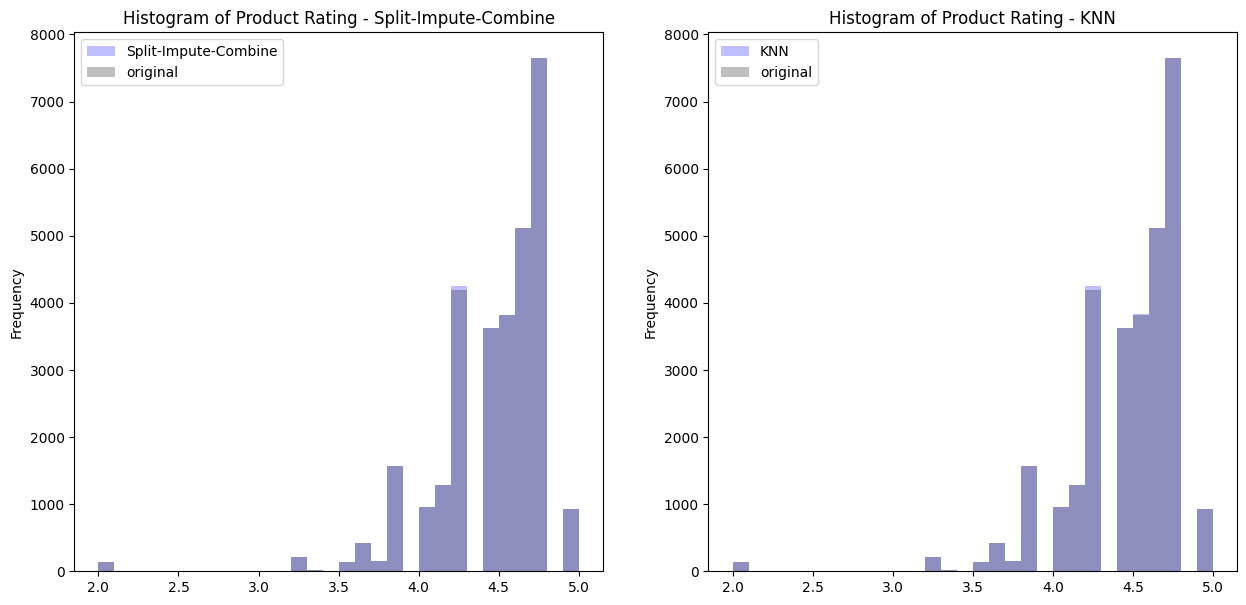

In [304]:
# (code from MachineLearningNotebook)

f = plt.figure(figsize=(15,7))

bin_num = 30
plt.subplot(1,2,1)
plt.title("Histogram of Product Rating - Split-Impute-Combine")
df_imputed_sic.product_rating.plot(kind='hist', alpha=0.25, 
                        label="Split-Impute-Combine",
                        color='blue',
                        bins=bin_num)

final_df.product_rating.plot(kind='hist', alpha=0.25, 
                        label="original",
                        color='black',
                        bins=bin_num)
plt.legend()

plt.subplot(1,2,2)

plt.title("Histogram of Product Rating - KNN")
df_imputed_knn.product_rating.plot(kind='hist', alpha=0.25, 
                        label="KNN",
                        color='blue',
                        bins=bin_num)

final_df.product_rating.plot(kind='hist', alpha=0.25, 
                        label="original",
                        color='black',
                        bins=bin_num)
plt.legend()




plt.show()

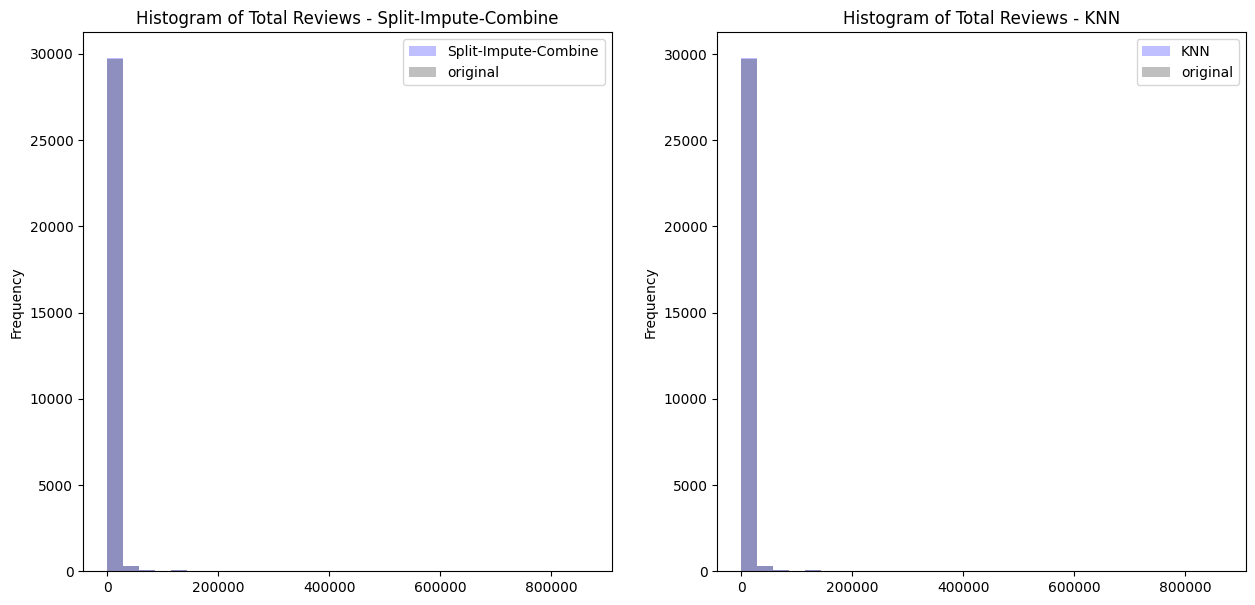

In [305]:
f = plt.figure(figsize=(15,7))

bin_num = 30
plt.subplot(1,2,1)

plt.title("Histogram of Total Reviews - Split-Impute-Combine")
df_imputed_sic.total_reviews.plot(kind='hist', alpha=0.25, 
                        label="Split-Impute-Combine",
                        color='blue',
                        bins=bin_num)

final_df.total_reviews.plot(kind='hist', alpha=0.25, 
                        label="original",
                        color='black',
                        bins=bin_num)
plt.legend()
plt.subplot(1,2,2)
plt.title("Histogram of Total Reviews - KNN")
df_imputed_knn.total_reviews.plot(kind='hist', alpha=0.25, 
                        label="KNN",
                        color='blue',
                        bins=bin_num)

final_df.total_reviews.plot(kind='hist', alpha=0.25, 
                        label="original",
                        color='black',
                        bins=bin_num)
plt.legend()


plt.show()

#### 2.4.6 Statistical Analysis Between Spilit-Impute-Combine and KNN

In [306]:
# (code from MachineLearningNotebook)

print("total_reviews stats for KNN Imputation")
knn_result = df_imputed_knn["total_reviews"].describe()
print(knn_result)

print("total_reviews stats for SIC Imputation")
sic_result = df_imputed_sic["total_reviews"].describe()
print(sic_result)

total_reviews stats for KNN Imputation
count     30304.000000
mean       3689.083428
std       14815.947854
min           1.000000
25%         165.000000
50%         686.000000
75%        2646.500000
max      865598.000000
Name: total_reviews, dtype: float64
total_reviews stats for SIC Imputation
count     30298.000000
mean       3691.252647
std       14817.028348
min           1.000000
25%         165.000000
50%         686.000000
75%        2649.750000
max      865598.000000
Name: total_reviews, dtype: float64


In [307]:
# (code from MachineLearningNotebook)

print("total_reviews stats for KNN Imputation")
knn_result = df_imputed_knn["product_rating"].describe()
print(knn_result)

print("total_reviews stats for SIC Imputation")
sic_result = df_imputed_sic["product_rating"].describe()
print(sic_result)

total_reviews stats for KNN Imputation
count    30304.000000
mean         4.438351
std          0.358686
min          2.000000
25%          4.300000
50%          4.500000
75%          4.700000
max          5.000000
Name: product_rating, dtype: float64
total_reviews stats for SIC Imputation
count    30298.000000
mean         4.438468
std          0.358651
min          2.000000
25%          4.300000
50%          4.500000
75%          4.700000
max          5.000000
Name: product_rating, dtype: float64



From the graphs, we can see that both are pretty good imputations of the missing values for Product Rating, and Total Reviews as we can mostly see that the graphs are being overlapped with one another. Interesting, both KNN and SIC have the same color shift at the top of around 4.4 bar. Which could indicate that the missing values were present there, and it was imputed correctly for both histograms.

Additionally, we have also included the statistics for both imputed columns for both KNN and SIC imputation. We can see that the mean and std for both are pretty similar as well, but knn has a better mean for both columns, but it is ever so slightly, and can be negligible, same for the standard deviations as well. However, knn has a higher count than SIC, which indicates that knn was able to impute more missing data, and with a similar mean, it did not add crazy imputation result.  

As such, both imputations can be used as the <b>Final Clean Data Set</b>, but we will go with KNN due to imputing more missing values for further analysis.

In [308]:
df_imputed_knn["total_reviews"] = df_imputed_knn['total_reviews'].astype(int)
df_imputed_knn["purchased_last_month"] = df_imputed_knn['purchased_last_month'].astype(int)

df_imputed_knn.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30304 entries, 0 to 42674
Data columns (total 31 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   product_rating                        30304 non-null  float64
 1   total_reviews                         30304 non-null  int64  
 2   purchased_last_month                  30304 non-null  int64  
 3   discounted_price                      30304 non-null  float64
 4   original_price                        30304 non-null  float64
 5   is_sponsored                          30304 non-null  float64
 6   discount_percentage                   30304 non-null  float64
 7   product_category_Cameras              30304 non-null  float64
 8   product_category_Chargers & Cables    30304 non-null  float64
 9   product_category_Gaming               30304 non-null  float64
 10  product_category_Headphones           30304 non-null  float64
 11  product_category_Lap

so our final cleaned dataset is created and named as "cleaned_df".

In [309]:
cleaned_df = copy.deepcopy(df_imputed_knn)
cleaned_df.info()
cleaned_df.nunique()

<class 'pandas.core.frame.DataFrame'>
Index: 30304 entries, 0 to 42674
Data columns (total 31 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   product_rating                        30304 non-null  float64
 1   total_reviews                         30304 non-null  int64  
 2   purchased_last_month                  30304 non-null  int64  
 3   discounted_price                      30304 non-null  float64
 4   original_price                        30304 non-null  float64
 5   is_sponsored                          30304 non-null  float64
 6   discount_percentage                   30304 non-null  float64
 7   product_category_Cameras              30304 non-null  float64
 8   product_category_Chargers & Cables    30304 non-null  float64
 9   product_category_Gaming               30304 non-null  float64
 10  product_category_Headphones           30304 non-null  float64
 11  product_category_Lap

product_rating                            37
total_reviews                           4063
purchased_last_month                      29
discounted_price                        3374
original_price                          2970
is_sponsored                               2
discount_percentage                     1487
product_category_Cameras                   2
product_category_Chargers & Cables         2
product_category_Gaming                    2
product_category_Headphones                2
product_category_Laptops                   2
product_category_Networking                2
product_category_Other Electronics         2
product_category_Phones                    2
product_category_Power & Batteries         2
product_category_Printers & Scanners       2
product_category_Smart Home                2
product_category_Speakers                  2
product_category_Storage                   2
product_category_TV & Display              2
product_category_Wearables                 2
is_best_se

## 3.Data Visualization

### 3.1 Attribute Visualization

#### 3.1.1 product_category

In [310]:
# create a new category column called "category_label" based on one-hot-encoding value
# (code from https://stackoverflow.com/questions/38334296/reversing-one-hot-encoding-in-pandas)
category_col = [c for c in cleaned_df.columns if c.startswith("product_category_")]
cleaned_df['category_label'] = pd.from_dummies(
    cleaned_df[category_col],
    sep="product_category_"
)

cleaned_df['category_label'].unique()

array(['Phones', 'Laptops', 'Other Electronics', 'Cameras', 'Storage',
       'Printers & Scanners', 'TV & Display', 'Power & Batteries',
       'Chargers & Cables', 'Headphones', 'Networking', 'Wearables',
       'Smart Home', 'Speakers', 'Gaming'], dtype=object)

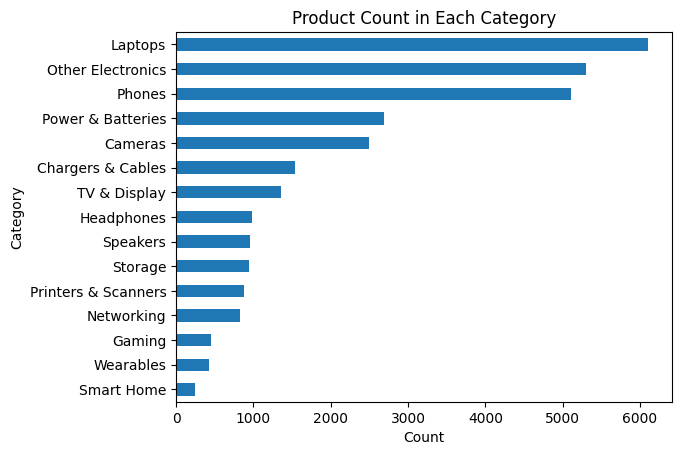

In [311]:
# create plot (code from MachineLearningNotebook)
cleaned_df['category_label'].value_counts().sort_values().plot(kind='barh')
plt.title("Product Count in Each Category")
plt.xlabel("Count")
plt.ylabel("Category")

# try log, but not necessary
#ax.set_xscale('log')

plt.show()

Since this is a categorical feature, we use a bar chart to visualize it, so that we can see the product distribution in the category.

According to the bar chart, Laptops, Other Electronics, and Phones have the most items, which have more than 5000 products. Other categories have much smaller product counts. So, the distribution is unbalanced, because a few big categories hold most of the products.

This result is intuitive because laptops and phones are the most needed items in daily life.


#### 3.1.2 original_price and discounted_price

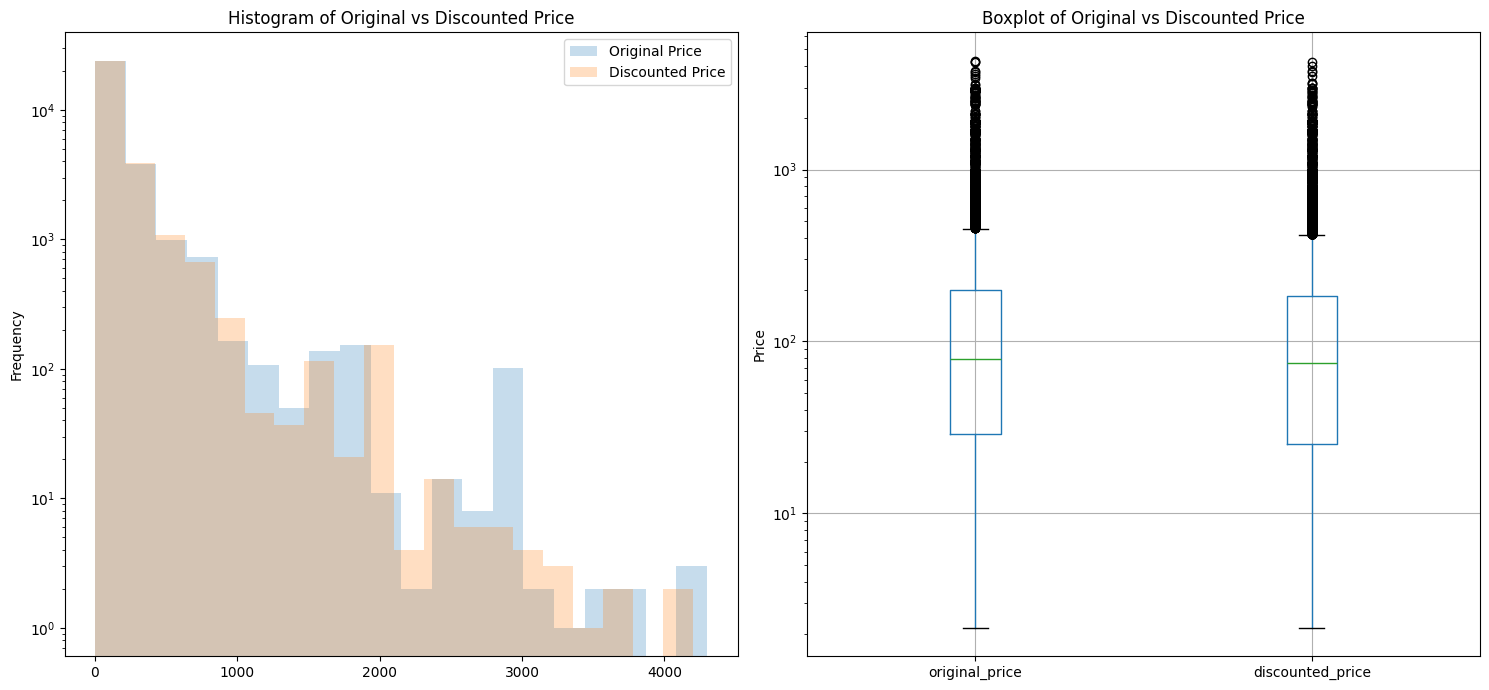

In [312]:
# create visualization of original_price and discounted_price (code from MachineLearningNotebook)

# set size 
fig = plt.figure(figsize=(15,7))

# create histogram
plt.subplot(1,2,1)
cleaned_df['original_price'].plot.hist(bins=20, alpha=0.25,  label='Original Price')
cleaned_df['discounted_price'].plot.hist(bins=20, alpha=0.25, label='Discounted Price')

plt.title('Histogram of Original vs Discounted Price')
plt.legend()

# log scale
plt.yscale('log')



# create box plot with two features
plt.subplot(1,2,2)
ax = cleaned_df.boxplot(column=['original_price', 'discounted_price'])

plt.ylabel('Price')
plt.title('Boxplot of Original vs Discounted Price')

# log scale
ax.set_yscale('log')

plt.tight_layout()
plt.show()



As we discussed in 2.3 Statistics Description, original_price and discounted_price are highly similar. So we create plots which contain both features, in that case, we can have a clear comparison of them.

The histogram shows that discounted_price is always slightly lower than original_price, and most product prices are below 500. The counts drop quickly as the price goes up. The boxplot confirms this. The median is near 100, and many products are close to the bottom. 

Moreover, there are many outliers in the high price area. These two plots also confirm that both original and discounted prices follow the same pattern.


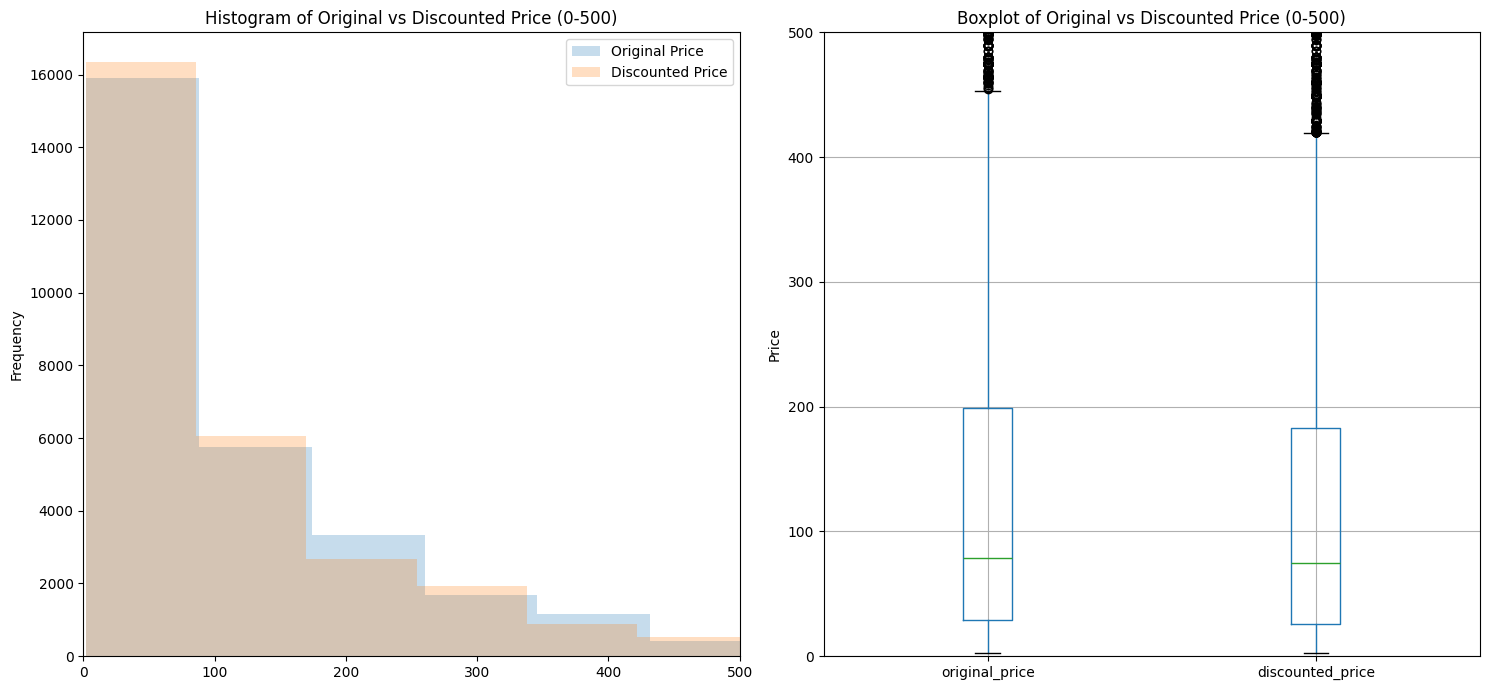

In [313]:
# create histogram and boxplot with price in [0-500] (code from MachineLearningNotebook)
fig = plt.figure(figsize=(15,7))

# create histogram
plt.subplot(1,2,1)
cleaned_df['original_price'].plot.hist(bins=50, alpha=0.25, label='Original Price')
cleaned_df['discounted_price'].plot.hist(bins=50, alpha=0.25, label='Discounted Price')
plt.title('Histogram of Original vs Discounted Price (0-500)')

plt.legend()
plt.xlim(0, 500)  # add range


# create box plot
plt.subplot(1,2,2)
ax = cleaned_df.boxplot(column=['original_price', 'discounted_price'])

plt.ylabel('Price')
plt.title('Boxplot of Original vs Discounted Price (0-500)')

ax.set_ylim(0, 500)   # add range


plt.tight_layout()
plt.show()



Since most product prices are under 500.

We dig deeper into the price range between 0 -500 to see the price distribution.

The histogram shows the same trend as the one before, the frequency goes down as the price grows. Original and discounted prices follow almost the same pattern. The boxplot showsthat  the median is below 80， and about 75% of the products are priced below 200. Many products are concentrated at a low price.


#### 3.1.3 discount_percentage

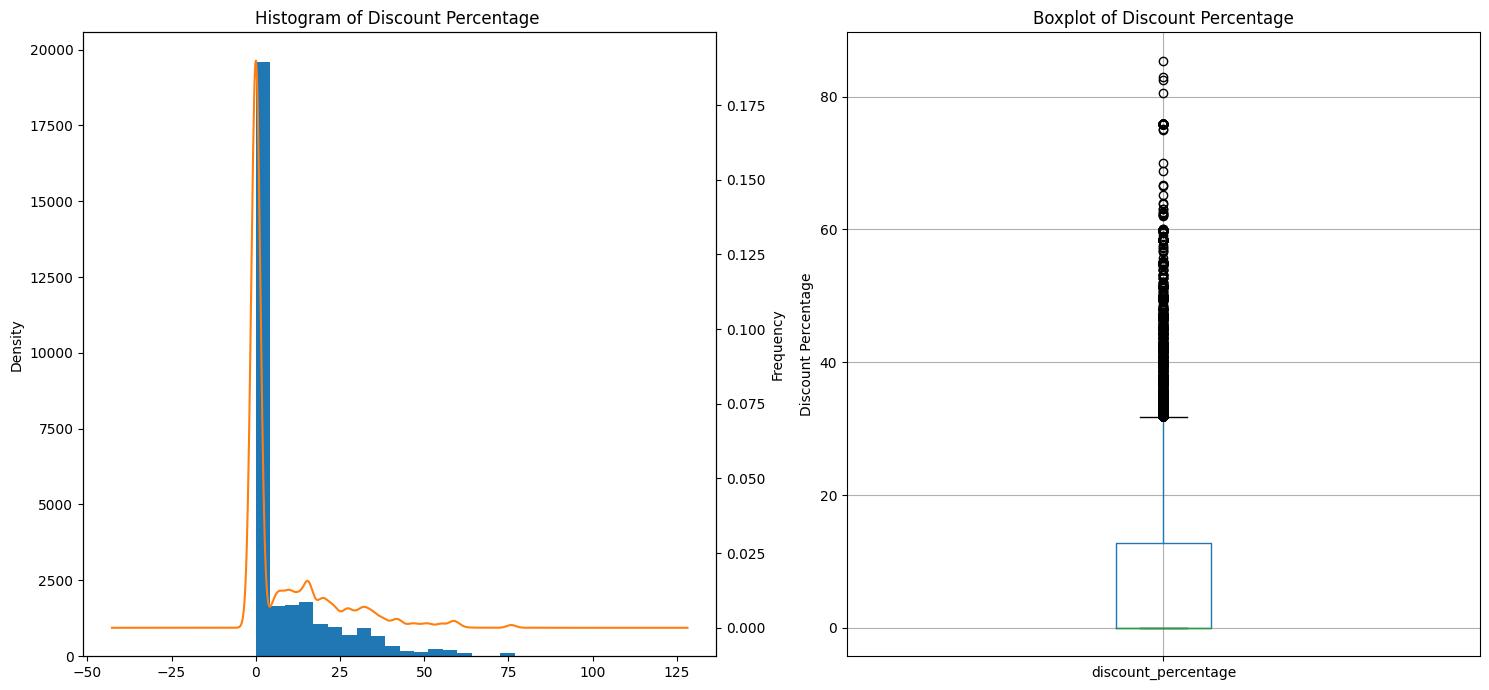

In [314]:
# create visualization of discount_percentage (code from MachineLearningNotebook)
fig = plt.figure(figsize=(15,7))

# histogram and KDE
plt.subplot(1,2,1)
cleaned_df['discount_percentage'].plot.hist(bins=20)
cleaned_df['discount_percentage'].plot.kde(bw_method=0.1, secondary_y=True)
plt.title('Histogram of Discount Percentage ')
plt.xlabel('Discount Percentage')
plt.ylabel('Frequency')

# boxplot
plt.subplot(1,2,2)
ax = cleaned_df.boxplot(column=['discount_percentage'])
plt.title('Boxplot of Discount Percentage')
plt.ylabel('Discount Percentage')

plt.tight_layout()
plt.show()

The discount_percentage is highly left-skewed.

Most products have a low discount percentage between 0 and 5%. The frequency drops as the discount grows, and only a few products reach over 40%.

The boxplot confirms this. The median discount is very low. Most products lie below 20%, while many outliers are higher, some above 80%.

In summary, discounts are rare and small, only a few products have very large discounts.

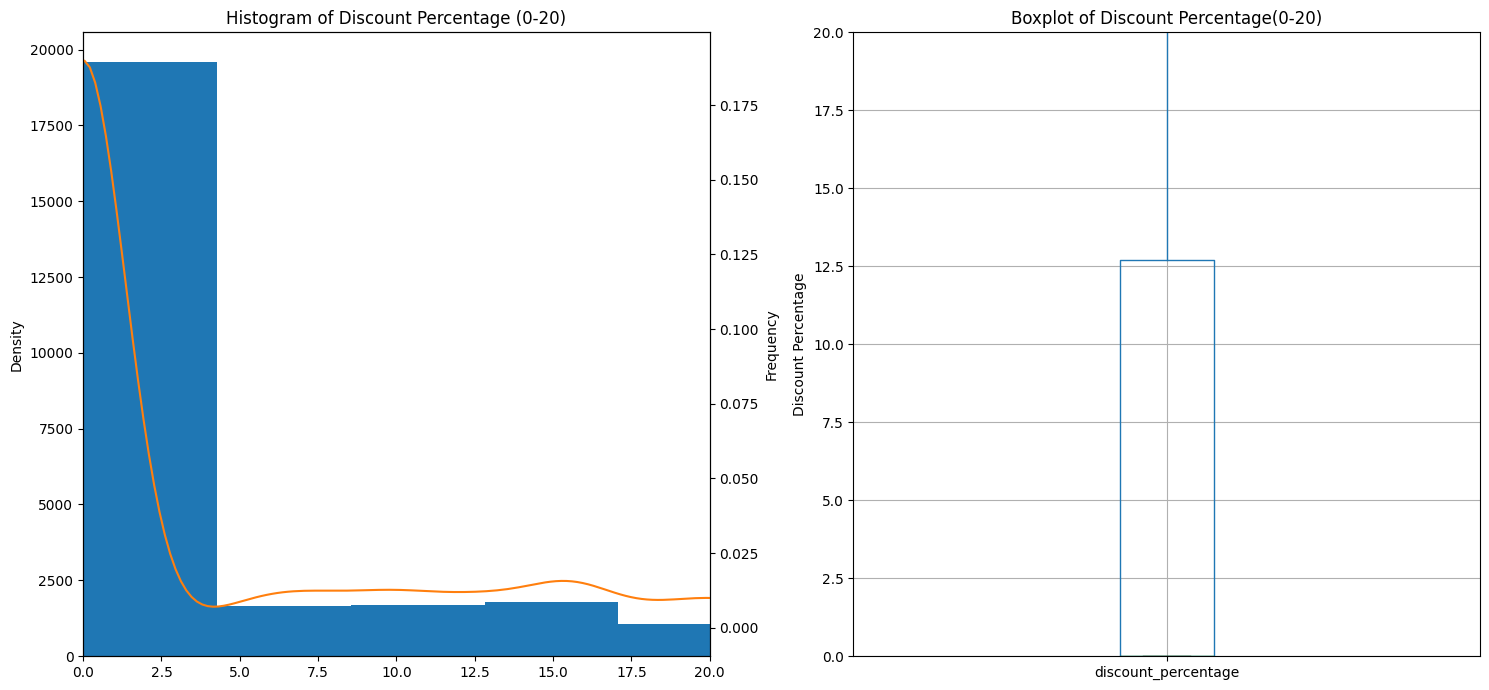

In [315]:

# create visualization of discount_percentage, range in 0-20 (code from MachineLearningNotebook)
fig = plt.figure(figsize=(15,7))

# histogram 
plt.subplot(1,2,1)
cleaned_df['discount_percentage'].plot.hist(bins=20)
cleaned_df['discount_percentage'].plot.kde(bw_method=0.1, secondary_y=True)
plt.title('Histogram of Discount Percentage (0-20)')
plt.xlabel('Discount Percentage')
plt.ylabel('Frequency')
plt.xlim(0, 20) # limited range

# boxplot 
plt.subplot(1,2,2)
ax = cleaned_df.boxplot(column=['discount_percentage'])
plt.title('Boxplot of Discount Percentage(0-20)')
plt.ylabel('Discount Percentage')
plt.ylim(0, 20) #limited range

plt.tight_layout()
plt.show()

We create new visualization with limited range of discount percentage, 0-20.

The histogram shows that most products cluster around very small discounts, close to 0–3%. The frequency drops quickly as the discount gets larger. The boxplot shows the median is low, around 0.

So, most products only offer slight discount.

#### 3.1.4 is_best_seller, is_sponsored

In [316]:
# create best_seller_laebl column, to represent one-hot-encoding is_best_seller
# (code from https://stackoverflow.com/questions/38334296/reversing-one-hot-encoding-in-pandas)

# find all the column
best_seller_col = [c for c in cleaned_df.columns if c.startswith("is_best_seller")]

# reverse one-hot-encoding
cleaned_df['best_seller_label'] = pd.from_dummies(
    cleaned_df[best_seller_col],
    sep="is_best_seller_"
)

cleaned_df['best_seller_label'].unique()


array(['No Badge', 'Best Seller', "Amazon's", 'Limited time deal',
       'Save 30%', 'Save 12%', 'Save 17%', 'Ends in', 'Save 18%'],
      dtype=object)

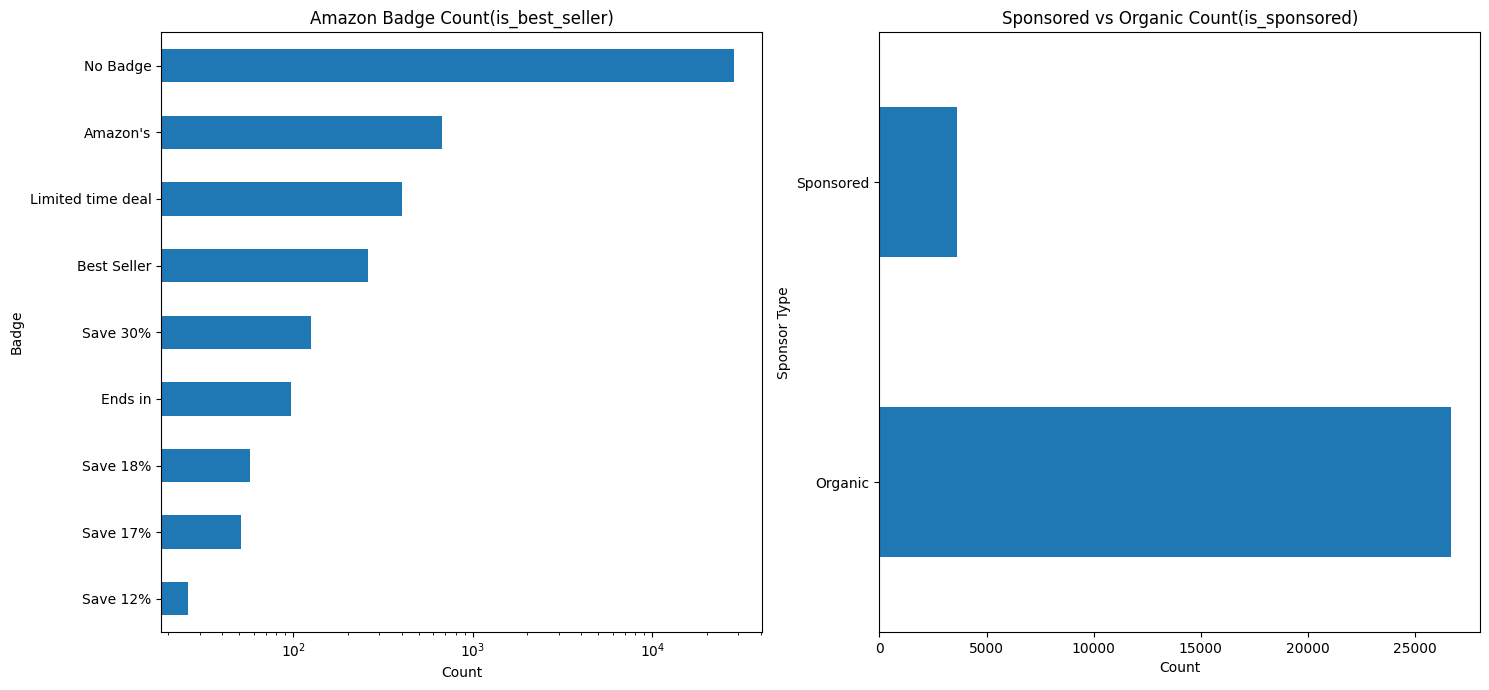

In [317]:
# create visualization of is_best_seller and is_sponsored (code from MachineLearningNotebook)
plt.figure(figsize=(15,7))

# create bar chart of best_seller_label
plt.subplot(1,2,1)
cleaned_df['best_seller_label'].value_counts().sort_values().plot(kind='barh')
plt.title("Amazon Badge Count(is_best_seller)")
plt.xlabel("Count")
plt.ylabel("Badge")

# better with log
plt.xscale('log')



# create bar chart of is_sponsored
plt.subplot(1,2,2)

#is_sponsored is a boolean, so just count
sponsored_count = cleaned_df['is_sponsored'].value_counts()
sponsored_count = sponsored_count.rename(index={0: "Organic", 1: "Sponsored"}) #replace 1 and 0 with sponsored vs organic

#create plot
ax = sponsored_count.plot(kind='barh')
plt.title("Sponsored vs Organic Count(is_sponsored)")
plt.xlabel("Count")
plt.ylabel("Sponsor Type")

# better with no log
# ax.set_xscale('log')  

plt.tight_layout()
plt.show()

The is_best_seller, is_sponsored are also categorical attributes, similar to product_category, so we use the same bar chart to visualize.

The first chart shows the distribution of the is_best_seller, with most products having No Badge. A smaller group has labels like Amazon’s, Limited-time deal, or saving percentage. The second chart shows is_sponsored, most items are Organic. Only a few are sponsored.

In summary, most products have no special badge and are not sponsored. Only a few carry promotional or sponsored tags.

#### 3.1.5 total_review

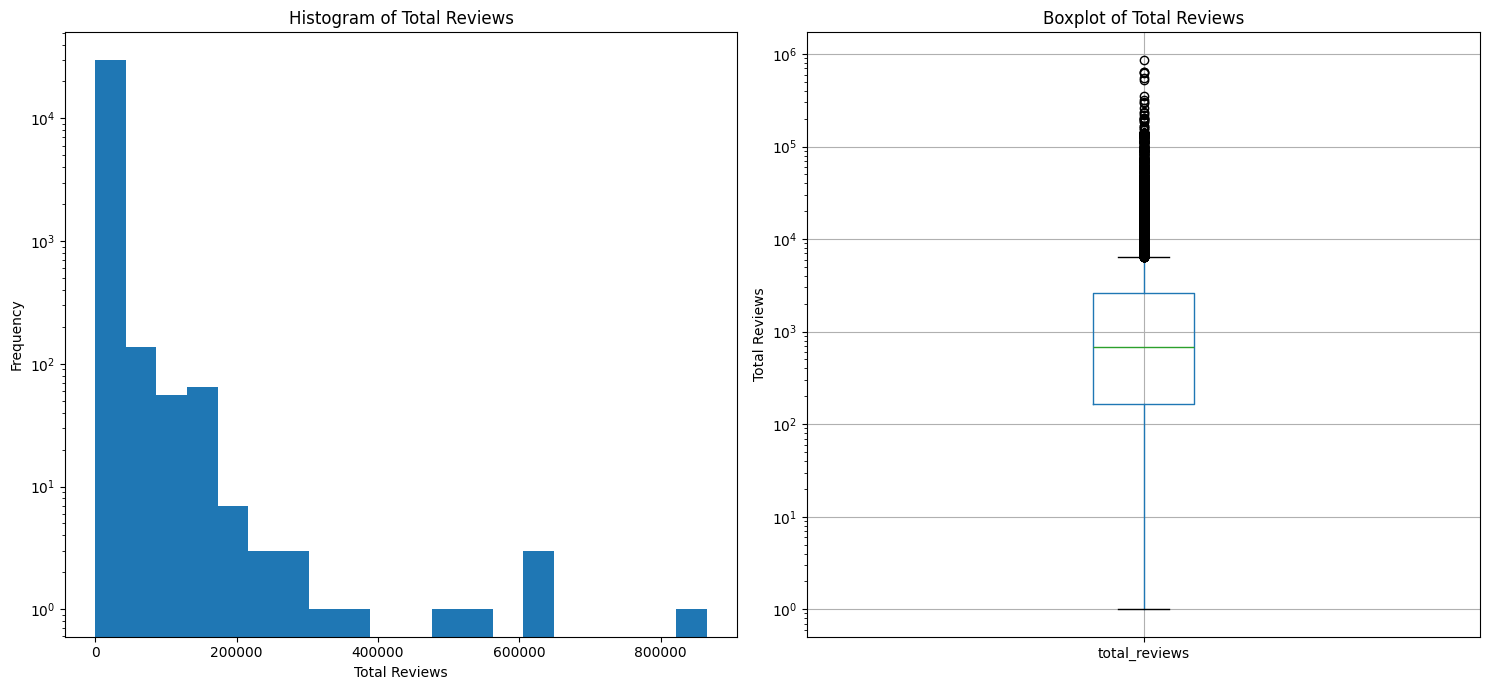

In [318]:
# create visualization of total_reviews (code from MachineLearningNotebook)
plt.figure(figsize=(15,7))

# histogram of total_review
plt.subplot(1,2,1)
cleaned_df['total_reviews'].plot.hist(bins=20)
plt.title('Histogram of Total Reviews')
plt.xlabel('Total Reviews')
plt.ylabel('Frequency')
# better with log
plt.yscale('log') 

# boxplot of total_review
plt.subplot(1,2,2)
ax = cleaned_df.boxplot(column=['total_reviews'])
plt.title('Boxplot of Total Reviews')
plt.ylabel('Total Reviews')
# better with log
ax.set_yscale('log')

plt.tight_layout()
plt.show()

The total_review is highly left-skewed.

The histogram shows that most products have very few reviews. Only a small group of products has more than 100,000 reviews, and these are extreme outliers. The boxplot confirms the skew, the median is a few hundred reviews. A few products have extremely high reviews.

In summary, reviews are highly uneven. Most items have only a little review, but there are still a few very popular ones that have massive review counts.

#### 3.1.6 product_rating

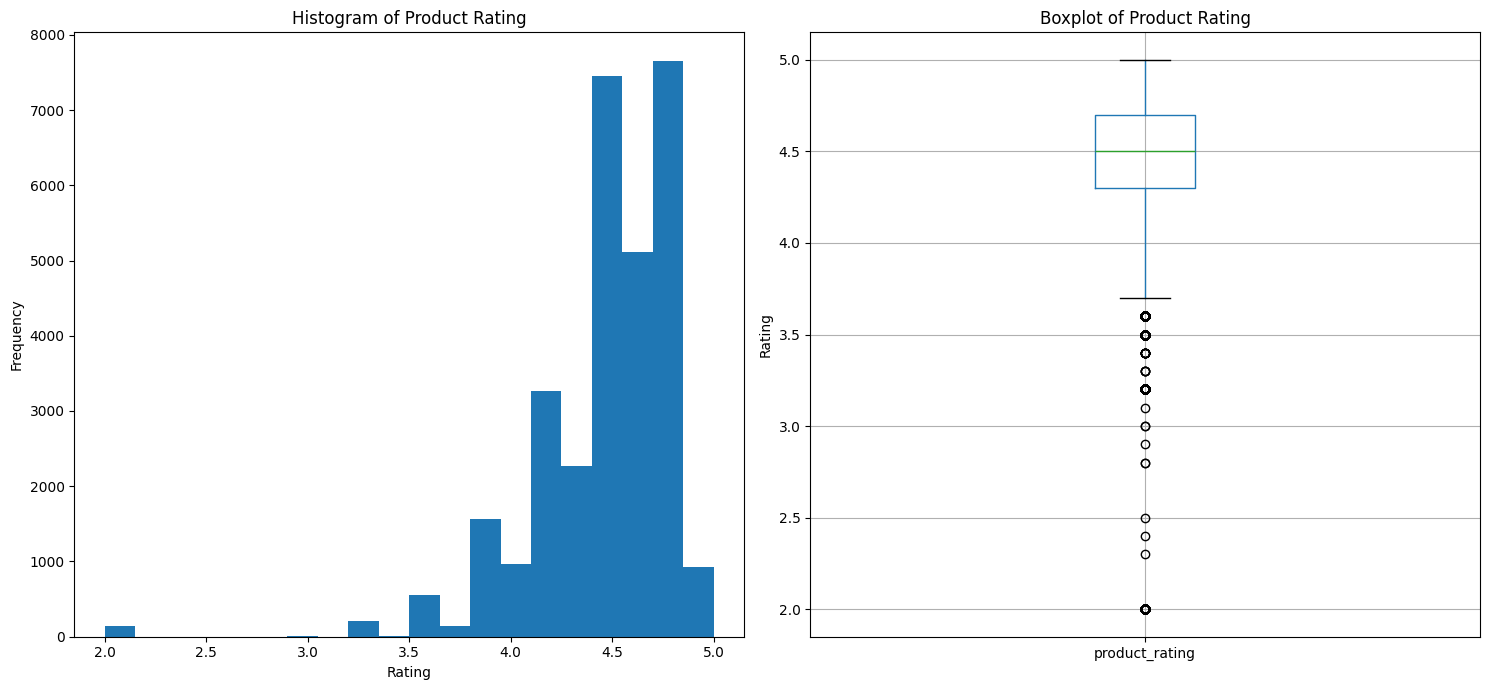

In [319]:
# create visualization of product_rating (code from MachineLearningNotebook)
plt.figure(figsize=(15,7))

# histogram
plt.subplot(1,2,1)
cleaned_df['product_rating'].plot.hist(bins=20)

plt.title('Histogram of Product Rating')
plt.xlabel('Rating')
plt.ylabel('Frequency')

# boxplot
plt.subplot(1,2,2)
ax = cleaned_df.boxplot(column=['product_rating'])
plt.title('Boxplot of Product Rating')
plt.ylabel('Rating')

plt.tight_layout()
plt.show()

The product_rating doesn't have a huge distance in the statistics description, and the histogram also shows that ratings are mostly high, which is between 4.0 and 5.0. And very few items have ratings below 3.5. The boxplot confirms this, the median rating is around 4.5, and the upper quartile is close to 5.


#### 3.1.7 purchase_last_month

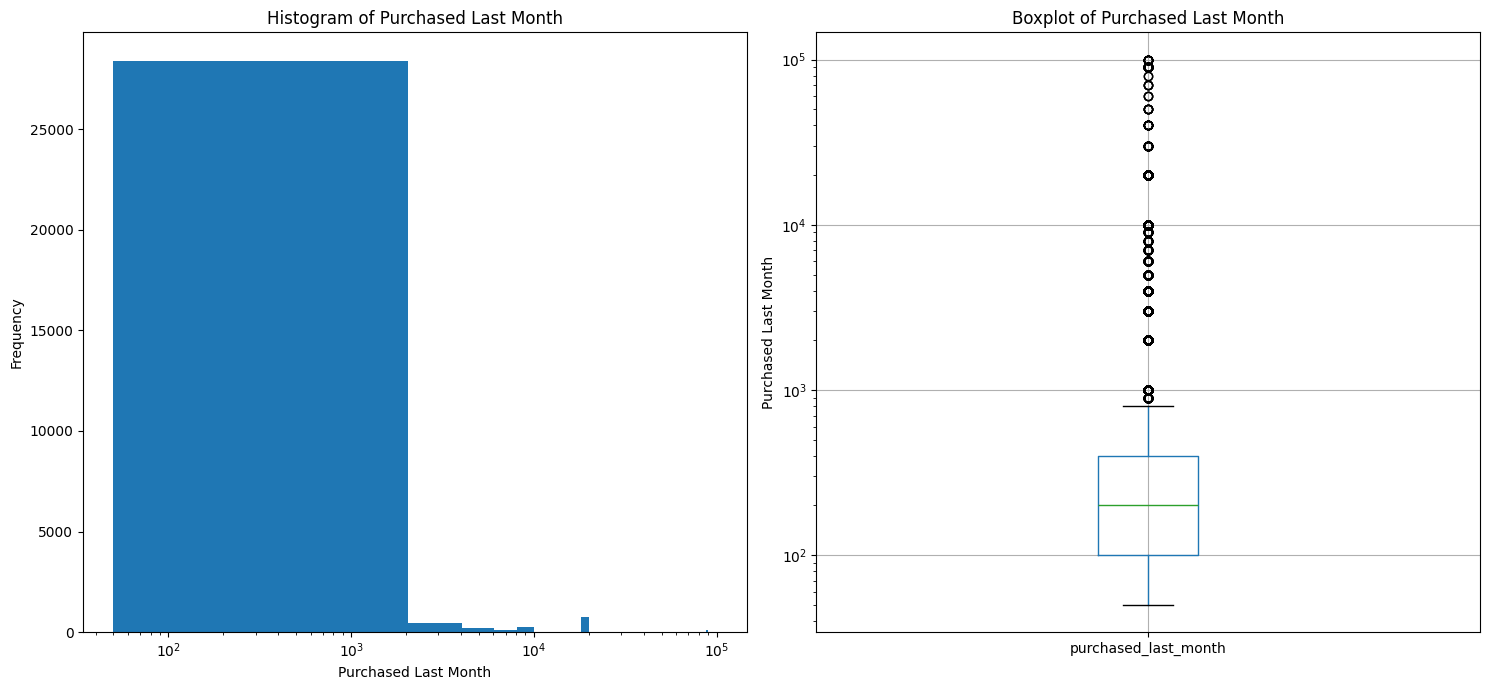

In [320]:
# create histogram and boxplot for purchase_last_month (code from MachineLearningNotebook)
plt.figure(figsize=(15,7))

# histogram
plt.subplot(1,2,1)
cleaned_df['purchased_last_month'].plot.hist(bins=50)
plt.title('Histogram of Purchased Last Month')
plt.xlabel('Purchased Last Month')
plt.ylabel('Frequency')
#plt.yscale('log') 
plt.xscale('log') 

# boxplot
plt.subplot(1,2,2)
ax = cleaned_df.boxplot(column=['purchased_last_month'])
plt.title('Boxplot of Purchased Last Month')
plt.ylabel('Purchased Last Month')
ax.set_yscale('log')  

plt.tight_layout()
plt.show()

The purchase_last_month is considered as the output attribute, we will use other attributes to predict purchase_last_month in our model. 

Even though other attributes are this month’s values, purchased_last_month can still be a reasonable output attribute, because n a real marketing strategy plan, the price and sponsor stay stable for weeks or months, and the price, promotion reflect the current market position of the product. So, using the purchase_last_month as the output attribute is useful for our model.

According to the plot, he histogram shows that most products only had a few purchases last month. The frequency drops quickly as sales increase, but a few products sold tens of thousands, which are extreme outliers. The boxplot confirms this. The median is low, only a few hundred units. Most products are near the bottom.

In summary, sales are very uneven. Most products sell little, while a few popular ones dominate the market.

### 3.2 Interesting Qustion Exploration

#### 3.2.1 How Do Discounts Affect Sales by Category

In [321]:
# create sales volume and revenue attributes to represent sales, and discount_flag to present discount type
# (code from Python intro and MachineLearningNotebook)

import pandas as pd
import matplotlib.pyplot as plt


# define sales_volume and sales_revenue
cleaned_df['sales_volume']  = cleaned_df['purchased_last_month']
cleaned_df['sales_revenue'] = cleaned_df['purchased_last_month'] * cleaned_df['discounted_price']

# add differentiate for discount vs no discount
cleaned_df['discount_flag'] = cleaned_df['discount_percentage'].apply(lambda x: 'No Discount' if x == 0 else 'Discounted')

# create product count, sales volume and revenue, group by category and discount_flag
count_by_cate = cleaned_df.groupby(['category_label','discount_flag']).size().unstack(fill_value=0)
volume_by_cate = cleaned_df.groupby(['category_label','discount_flag'])['sales_volume'].sum().unstack(fill_value=0)
revenue_by_cate = cleaned_df.groupby(['category_label','discount_flag'])['sales_revenue'].sum().unstack(fill_value=0)

# sort by category
count_by_cate  = count_by_cate.loc[count_by_cate.sum(axis=1).sort_values().index]
volume_by_cate = volume_by_cate.loc[volume_by_cate.sum(axis=1).sort_values().index]
revenue_by_cate = revenue_by_cate.loc[revenue_by_cate.sum(axis=1).sort_values().index]

cleaned_df[['category_label', 'sales_volume', 'sales_revenue', 'discount_flag']].head()

,category_label,sales_volume,sales_revenue,discount_flag
0,Phones,300,26904.0,Discounted
1,Laptops,6000,59940.0,Discounted
2,Laptops,2000,628000.0,Discounted
3,Phones,10000,1622400.0,No Discount
4,Phones,10000,727400.0,No Discount


We already know that categories like laptops, phones, and other electronics have the most products in 3.1.1. However, product count does not mean sales outcomes.

So, we create two attributes as sales volume and sales revenue, and split them by discount or no discount, then do the visualization.


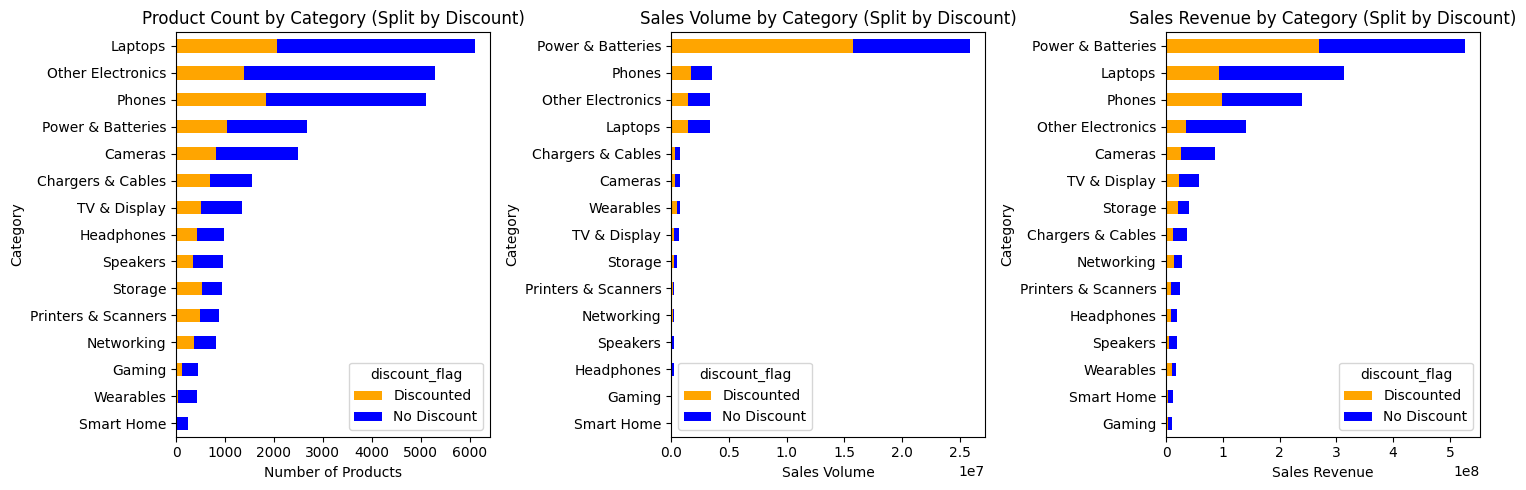

In [328]:

# create visualization of discount effect in categories (code from MachineLearningNotebook)
plt.figure(figsize=(15, 5))

# product category count bar
plt.subplot(1, 3, 1)
count_by_cate.plot(kind='barh', stacked=True, ax=plt.gca(), color=['orange','blue'])
plt.title('Product Count by Category (Split by Discount)')
plt.xlabel('Number of Products')
plt.ylabel('Category')

# sales volume bar
plt.subplot(1, 3, 2)
volume_by_cate.plot(kind='barh', stacked=True, ax=plt.gca(), color=['orange','blue'])
plt.title('Sales Volume by Category (Split by Discount)')
plt.xlabel('Sales Volume')
plt.ylabel('Category')

# sales revenue bar
plt.subplot(1, 3, 3)
revenue_by_cate.plot(kind='barh', stacked=True, ax=plt.gca(), color=['orange','blue'])
plt.title('Sales Revenue by Category (Split by Discount)')
plt.xlabel('Sales Revenue')
plt.ylabel('Category')

plt.tight_layout()
plt.show()


According to the visualization, power & batteries only have half of the product type than laptops, phones, and other electronics, but it has the biggest sales volume and sales revenue. This means that people buy power & batteries much more often than other categories. For phones and laptops, although the sales volume is lower, their higher price makes their sales revenue still not bad. So, price also matters, not only how many items are sold.

For the discount. In power & batteries, a very large part of sales comes from discounted products. This shows that discounts drive a lot of purchases in this category. But, for other categories like laptops and phones, the share of discounted products is much smaller. Which means consumers make decisions not totally rely on discounts. 

So, for sellers, a discount is not always important. In some categories, like power & batteries, discounts may be competitive. But in other categories, like phones or laptops, the product itself and its price might matter more than the discount.

#### 3.2.2 How Do Sponsorships Affect Sales by Category？

In [323]:
# create sales volume and revenue attributes to represent sales, and sponsor_label to present sponsor type (code from 3.2.1 section)
cleaned_df['sponsor_label'] = cleaned_df['is_sponsored'].replace(
    {0: "Organic", 1: "Sponsored"}
)

# product count by category and sponsor
count_by_sponsor = cleaned_df.groupby(['category_label', 'sponsor_label']).size().unstack(fill_value=0)

# sales volume by category and sponsor
volume_by_sponsor = cleaned_df.groupby(['category_label', 'sponsor_label'])['sales_volume'].sum().unstack(fill_value=0)

# sales revenue by category and sponsor
revenue_by_sponsor = cleaned_df.groupby(['category_label', 'sponsor_label'])['sales_revenue'].sum().unstack(fill_value=0)

# sort
count_by_sponsor   = count_by_sponsor.loc[count_by_sponsor.sum(axis=1).sort_values().index]
volume_by_sponsor  = volume_by_sponsor.loc[volume_by_sponsor.sum(axis=1).sort_values().index]
revenue_by_sponsor = revenue_by_sponsor.loc[revenue_by_sponsor.sum(axis=1).sort_values().index]

cleaned_df[['category_label', 'sales_volume', 'sales_revenue', 'sponsor_label']].head()

,category_label,sales_volume,sales_revenue,sponsor_label
0,Phones,300,26904.0,Sponsored
1,Laptops,6000,59940.0,Sponsored
2,Laptops,2000,628000.0,Sponsored
3,Phones,10000,1622400.0,Organic
4,Phones,10000,727400.0,Organic


To analyze the sponsorship influence, we follow the same method of discount analysis. We split the count, sales volume, sales revenue into sponsored and organic, and created the visualization.

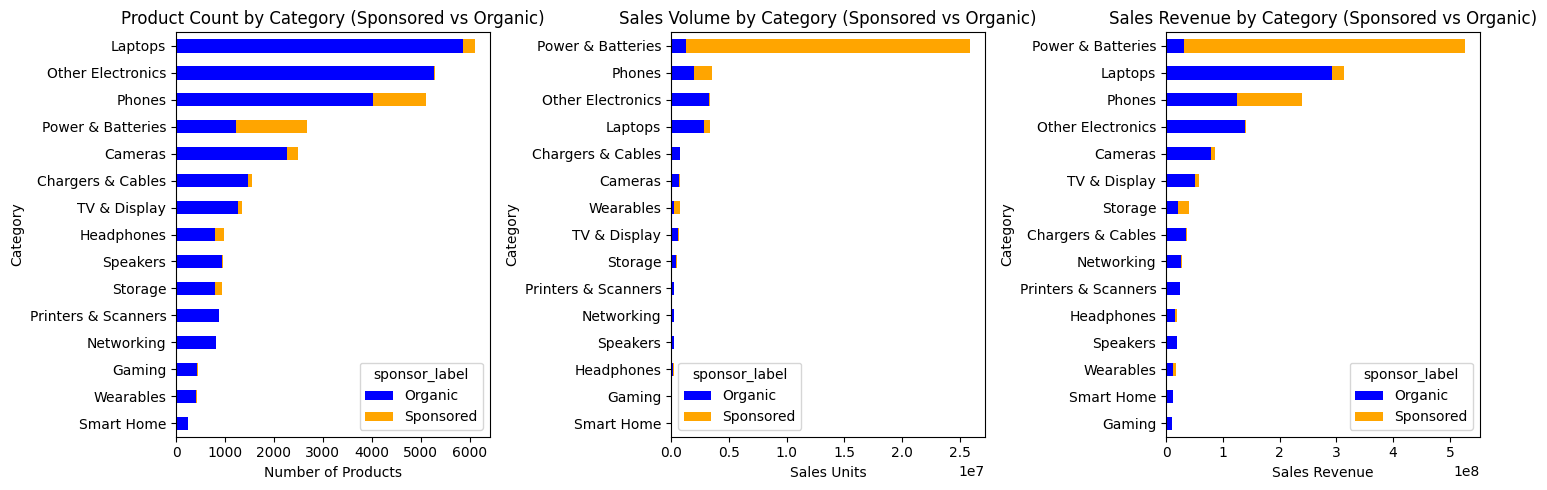

In [324]:

# create visualization of sponsorship effect in categories (code from 3.2.1 section)
plt.figure(figsize=(15, 5))

# product count by sponsor
plt.subplot(1, 3, 1)
count_by_sponsor.plot(kind='barh', stacked=True, ax=plt.gca(), color=['blue','orange'])
plt.title('Product Count by Category (Sponsored vs Organic)')
plt.xlabel('Number of Products')
plt.ylabel('Category')

# sales volume by sponsor 
plt.subplot(1, 3, 2)
volume_by_sponsor.plot(kind='barh', stacked=True, ax=plt.gca(), color=['blue','orange'])
plt.title('Sales Volume by Category (Sponsored vs Organic)')
plt.xlabel('Sales Units')
plt.ylabel('Category')

# sales revenue by sponsor
plt.subplot(1, 3, 3)
revenue_by_sponsor.plot(kind='barh', stacked=True, ax=plt.gca(), color=['blue','orange'])
plt.title('Sales Revenue by Category (Sponsored vs Organic)')
plt.xlabel('Sales Revenue')
plt.ylabel('Category')

plt.tight_layout()
plt.show()



From the result, we can see that more than 50% power & batteries product is sponsored, and almost all the sales volume and revenue are sponsored, so sponsorship plays a very strong role in this category. Phones and laptops also have some sponsored products, but the outcomes are not as extreme as in power & batteries, many sales are still from organic.

So, for sellers, the effect of sponsorship is not the same across categories. In power & batteries, sponsorship seems to be essential for sales. But in laptops and phones, organic sales are still very important. In other words, investing in sponsorship may be necessary to compete, while in others, having a strong product and good pricing might be enough.

#### 3.2.3 Which Attribute Contribute Most For Purchase

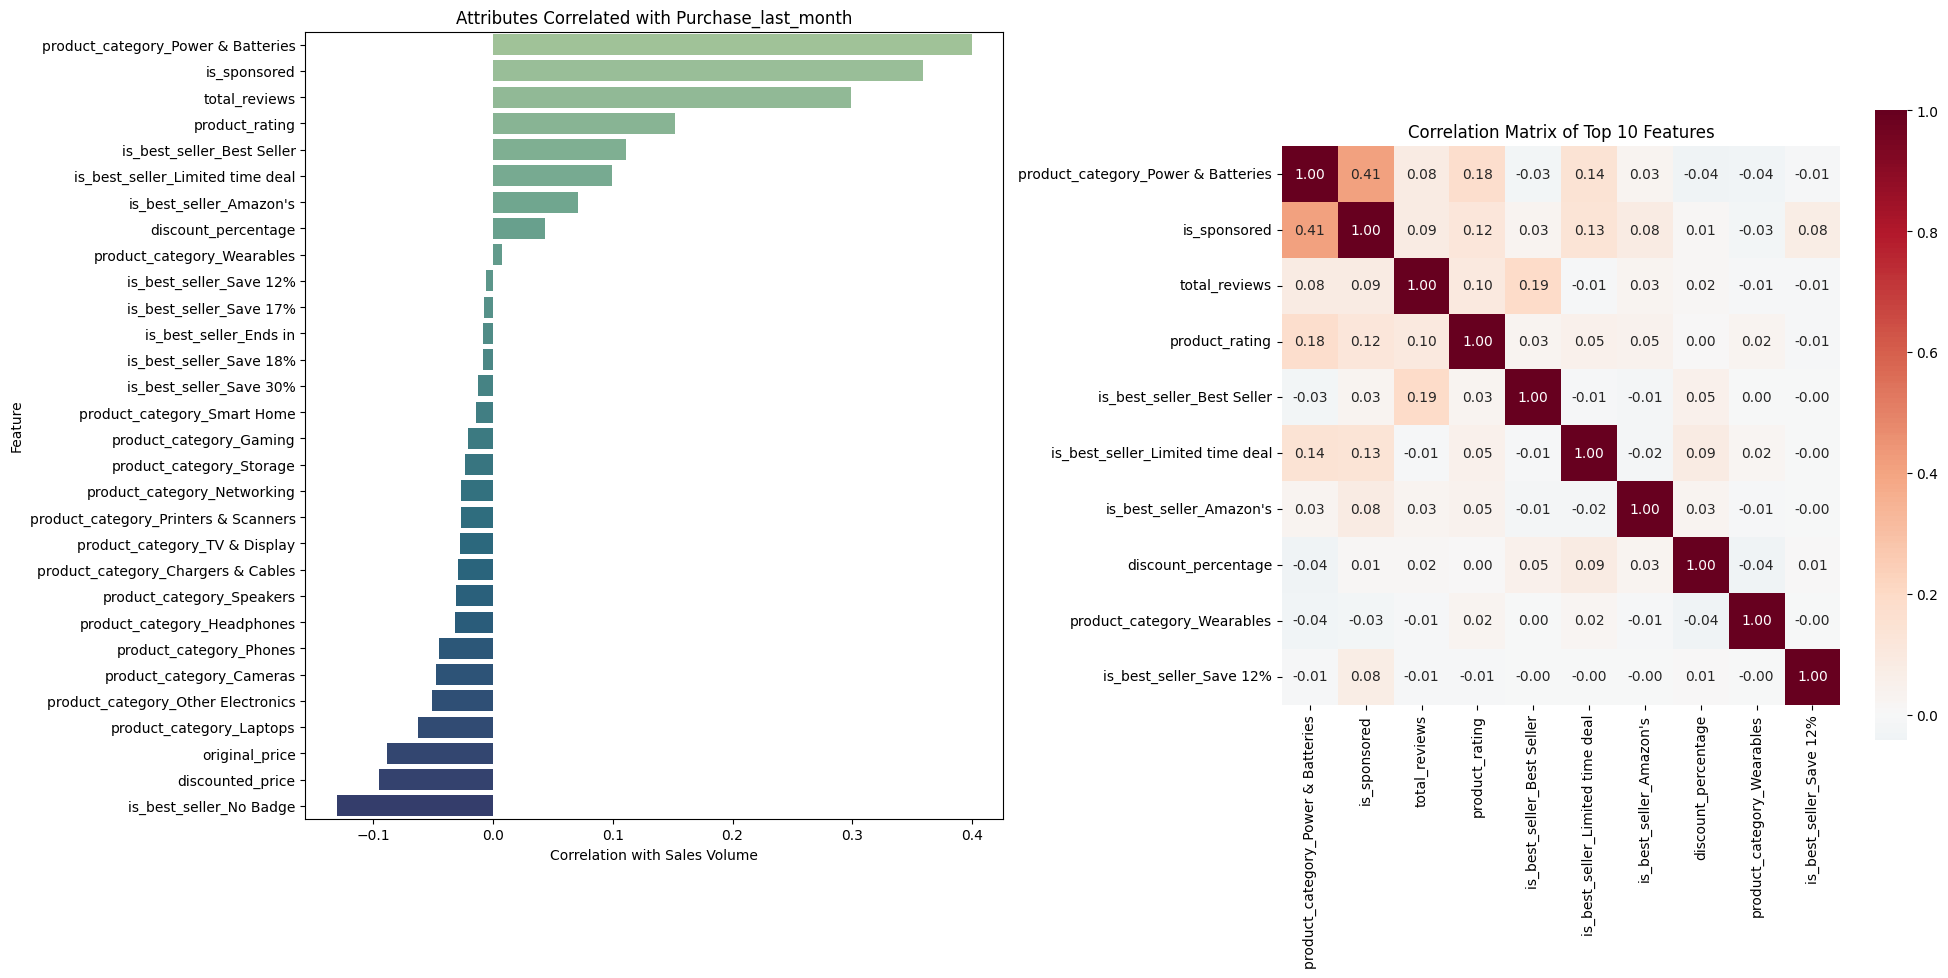

In [325]:
import seaborn as sns
#Ask gpt to fix a correlation matrix error, and plot graphs side by side. 

numeric_df = cleaned_df.select_dtypes(include=['number'])
correlations = numeric_df.corr()['purchased_last_month'].sort_values(ascending=False)

filtered_corr = correlations.drop(['sales_volume', 'purchased_last_month' , 'sales_revenue'])

#Getting Top 10 attributes from the bar chart
top_meaningful_corr = filtered_corr.head(10)
top_features = top_meaningful_corr.index.tolist()

subset_corr = numeric_df[top_features].corr()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

#Bar Chart
sns.barplot(x=filtered_corr.values, y=filtered_corr.index, palette="crest", ax=ax1)
ax1.set_title("Attributes Correlated with Purchase_last_month")
ax1.set_xlabel("Correlation with Sales Volume")
ax1.set_ylabel("Feature")

#Correlation Matrix
sns.heatmap(subset_corr, 
            annot=True, 
            cmap='RdBu_r', 
            center=0,
            square=True,
            fmt='.2f',
            cbar_kws={"shrink": .8},
            ax=ax2)
ax2.set_title("Correlation Matrix of Top 10 Features", fontsize=12)

# Adjust layout and display
plt.tight_layout()
plt.show()

We were curious what attributes contribute to the purchase of a product, as the seller can then optimize what needs to be done in order to increase their sales. So we created two graphs: Bar Chart, and a Correlation Matrix, as a bar chart can give us a quick visualization of which attribute has the highest purchase_last_month, while the correlation matrix can be used to see which combination of tags contributed the most to sale of the product. 

From the Bar Chart below, we can see that product category of Power and batteries, sponsored, and total rating led the chart with the highest purchase_last_month followed by product rating, Best seller, etc. This make sense as consumer would tend to trust other people reviews, and experience when it comes to making a purchase. All other positive correlation also makes sense as those tags tend to drive more traffic to their product page, and with many positive tags, it would also increase the sale of that product as well. Interesting we can see that batteries and power lead the chart, which is interesting as there are no supporting tag that contributes to the sale, so we need to look further in correlation matrix. 

From the top 10 attributes of the bar chart, we created a correlation matrix as well to see which attribute contributed to the sales of the product. We can see that batteries and power, has a high relationship with the product being sponsored or not, total reviews, product rating, and being limited time deal. This makes sense as power and batteries, can include items like power bank, which is used to charged phones, laptops etc, or Uninterruptible power supply which is really important item to have as well since most electronics need a stable voltage, and is a good backup electricity to used in case of a power outage. These items tend to be saturated in the market places, they also tend to be expensive as well, and they also have a risk of it catching on fire. As a result, having trusted people backing up the product by sponsorship, rating as well as it being limited time deal can influence people to think that this is a great product to buy. 

Overall, sales are most influenced by product sponsorship, reviews, rating. Sellers aiming to boost their sales should focus on building trust through reviews, investing in product sponsorship by reaching to influential reviewers in the Power and Batteries category.

## 4. Brief Summary 

Overall, the report makes sense and provides many interesting findings on attributes and their relations.

Every block of code indicates the resources, and most are from MachineLearningNoteBook and LabOne Example.

Our business analysis is aimed at predicting the product purchase amount based on given marketing strategies (discount, sponsor, review management, etc.). Since the target output is numeric, the report doesn't answer our questions directly. 

However, according to our attributes and interesting questions exploration, the report gives us a glance of view that marketing strategy has a significant influence on sales outcomes, and they are not the same in every category. 

For example, the correlation exploration of attributes shows that category, sponsorship, review number, rating, best seller badge, and discount all have an impact on the sales outcomes. The category exploration shows that although the laptops category and phones category have the largest amount of product types, the batteries & powers category has the most sales volume and revenue. Moreover, sellers in the batteries & powers category spend much more effort on applying marketing promotions, and most of the purchases are sponsored and discounted. And, the number of total reviews is more important for the sales revenue than the product ratings. 

All the findings are evidence, showing that our attribute selection is reasonable and useful for our predictive model. By using this dataset, we will create a practical and useful sales prediction model for Amazon electronic sellers.


## 5. Additional Analysis: Option B

In [326]:
# code from https://umap-learn.readthedocs.io/en/latest/basic_usage.html and debug with GPT

import umap
from sklearn.preprocessing import StandardScaler

umap_df = cleaned_df.drop(columns=["sales_volume", "sales_revenue", "purchased_last_month", "category_label", "discount_flag","sponsor_label","best_seller_label"])
scaler = StandardScaler()
scaled_feature = scaler.fit_transform(umap_df)

umap_data_1 = umap.UMAP(n_neighbors=15, min_dist=0.05, n_components=2, metric="euclidean")
umap_data_2 = umap.UMAP(n_neighbors=30, min_dist=0.1, n_components=2, metric="euclidean")
umap_data_3 = umap.UMAP(n_neighbors=50, min_dist=0.5, n_components=2, metric="euclidean")

umap_2d_data_1 = umap_data_1.fit_transform(scaled_feature)
umap_2d_data_2 = umap_data_2.fit_transform(scaled_feature)
umap_2d_data_3 = umap_data_3.fit_transform(scaled_feature)


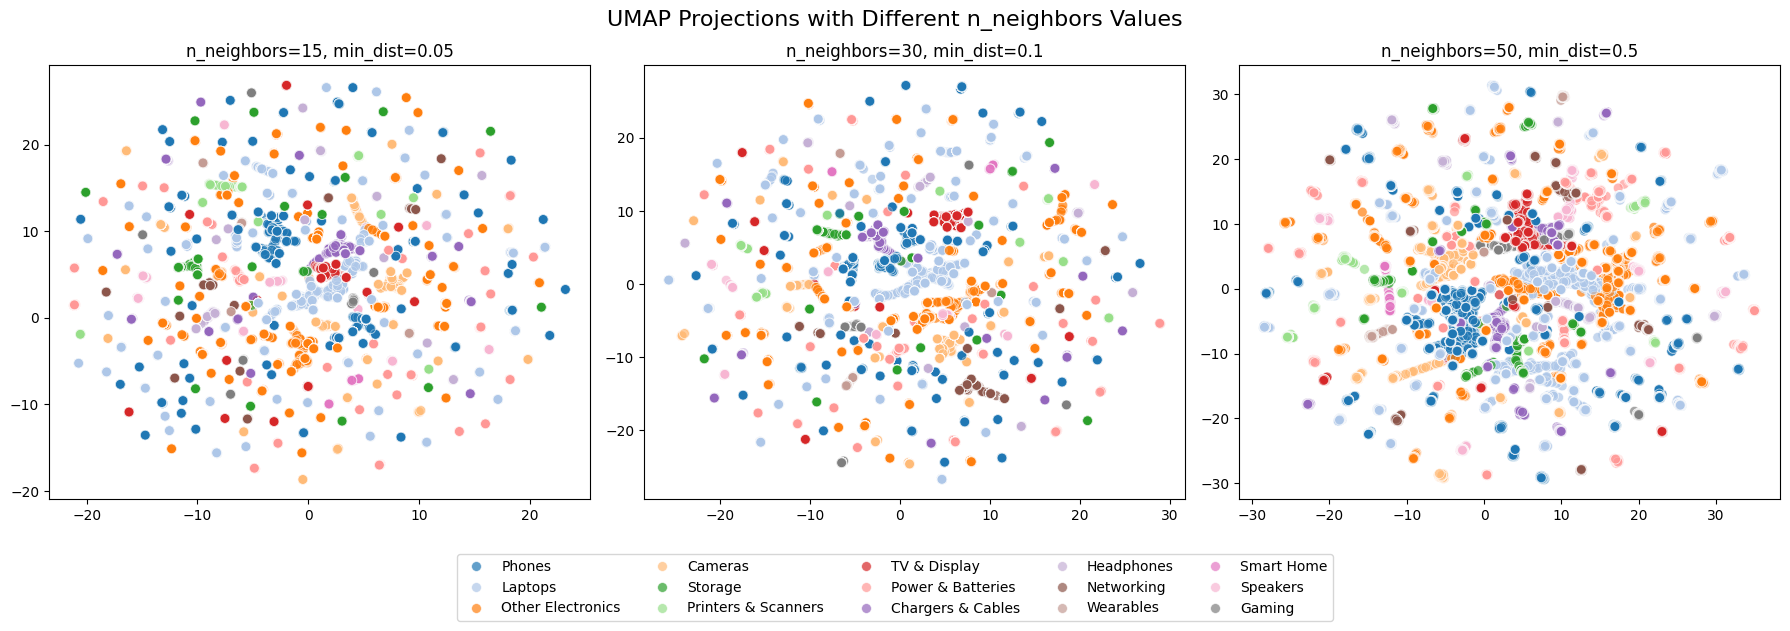

In [327]:
#Asked gpt to make the graph more readable, and colorblind friendly 
plt.figure(figsize=(18, 6))

unique_classes = cleaned_df["category_label"].nunique()
palette = sns.color_palette("tab20", unique_classes)

plt.subplot(1, 3, 1)
sns.scatterplot(x=umap_2d_data_1[:,0], y=umap_2d_data_1[:,1], 
                hue=cleaned_df["category_label"], 
                palette=palette, s=50, alpha=0.7)
plt.title("n_neighbors=15, min_dist=0.05")


plt.subplot(1, 3, 2)
sns.scatterplot(x=umap_2d_data_2[:,0], y=umap_2d_data_2[:,1], 
                hue=cleaned_df["category_label"], 
                palette=palette, s=50, alpha=0.7)
plt.title("n_neighbors=30, min_dist=0.1")


plt.subplot(1, 3, 3)
sns.scatterplot(x=umap_2d_data_3[:,0], y=umap_2d_data_3[:,1], 
                hue=cleaned_df["category_label"], 
                palette=palette, s=50, alpha=0.7)
plt.title("n_neighbors=50, min_dist=0.5")

handles, labels = plt.gca().get_legend_handles_labels()
plt.figlegend(handles, labels, loc='lower center', ncol=min(5, len(labels)), 
  bbox_to_anchor=(0.5, -0.05))

for ax in plt.gcf().axes:
  ax.get_legend().remove()

plt.tight_layout(rect=[0, 0.1, 1, 0.95]) 
plt.suptitle("UMAP Projections with Different n_neighbors Values", fontsize=16)
plt.show()

<b> UMAP Analysis result on Product category label </b>

From the three results, the parameter of n_neighbors 30, with the min_dist of 0.1 yielded the best result out of the three parameters. With a n_neighbour of 30, it is more focused on the global structure, and with a min_dist of 0.1, it indicates that points on the graph will be close to each other. After looking at the result, we can see that all of them are in a circular shape, where most of the correlations are of a similar category. For the middle graph, we can see that some of the categories are similar to one another, like cameras, laptops, phones, and other electronics are close to one another, and this result is correct in reality as since the common features between them are all cameras. The Left photo shows a mix of tight and loose spreads, while the right shows each category being grouped next to one another. However, the power&batteries stand out more clearly, which means they could make marketing easier. Although all the graphs are similar to one another, what we can take away from this is that providing meaningful product categories, which the seller can use this result to either sell, or create a product which have all the closely related categories in hopes of having a higher chance of these products being sold.